## 📊 Análisis de Supervivencia y Mantenimiento Predictivo de Motores a reacción CMAPSS

**Autores**: Isaac David Sánchez Sánchez, Germán Eduardo de Armas Castaño, Katlyn Gutiérrez Cardona, Shalom Jhoanna Arrieta Marrugo
**Curso**: Modelos de Regresión y Series de Tiempo con Aplicaciones en IA  
**Universidad**: Universidad Tecnológica de Bolívar - Grupo G, NCR 1705  
**Fecha**: Noviembre 2025

---

## 1. Comprensión del Problema de Negocio

**Resumen Ejecutivo**
<hr style="border: 1px solid #ddd;">

Esta sección explica los fundamentos que motivan el desarrollo del proyecto de mantenimiento predictivo de motores jet, define el problema a resolver y establece los objetivos finales que se buscan alcanzar mediante el análisis de datos de sensores.

**Objetivos de la Investigación**
<hr style="border: 1px solid #ddd;">

Esta etapa es fundamental para determinar las metas del proyecto, definir el problema de negocio y establecer los criterios de éxito que permitirán evaluar la efectividad de las soluciones propuestas.

### 1.1 Contexto y Motivación del Proyecto

Los motores jet constituyen uno de los componentes más críticos en la industria aeroespacial de la NASA. Estos sistemas de propulsión son esenciales para generar la fuerza de empuje necesaria que permite a las aeronaves alcanzar y mantener el vuelo. 

Dada la importancia crucial de estos motores en la seguridad operacional, se requiere un sistema robusto de análisis que permita predecir el estado de salud de cada motor, determinando si opera dentro de parámetros normales o si requiere mantenimiento preventivo. Esta capacidad predictiva es fundamental para evitar fallos catastróficos inesperados que podrían comprometer la integridad del vehículo y la seguridad de la misión.

Una de las metodologías más efectivas para evaluar el rendimiento de los motores es mediante el uso de **sensores especializados**. Estos dispositivos monitorizan continuamente múltiples parámetros operacionales tales como:

- 🌡️ **Temperatura:** Mediciones térmicas en diferentes componentes del motor
- 🔄 **Revoluciones:** Velocidad de rotación de los componentes rotatorios
- 📊 **Presión:** Niveles de presión en las cámaras de combustión y conductos
- 📳 **Vibraciones:** Patrones de vibración que pueden indicar desgaste mecánico

En este proyecto, desarrollaremos un **sistema de análisis predictivo** que permita clasificar el estado de salud de los motores basándose en los datos históricos de sensores, antes de que se produzca un fallo catastrófico.

### 1.2 Definición del Problema

**Problemática Central:** El desconocimiento sobre el estado de salud real de los motores puede ocasionar fallos catastróficos inesperados durante la operación, comprometiendo la seguridad de las misiones y la integridad de los activos.

### 1.3 Solución Propuesta

**Enfoque Metodológico:** Desarrollar un sistema de clasificación supervisada que determine el estado de salud de los motores, categorizándolos como **"normales"** o en **"fallo inminente"**, utilizando patrones extraídos de los datos históricos de sensores mediante técnicas de Machine Learning.

### 1.4 Perspectiva Empresarial e Impacto Industrial

Este proyecto trasciende el ámbito aeroespacial y puede aplicarse a cualquier sistema industrial que cuente con monitoreo mediante sensores. Por ejemplo, en el **sector manufacturero**, las máquinas de producción requieren vigilancia constante para prevenir paros inesperados durante los procesos productivos.

**Consecuencias de fallos no previstos en entornos industriales:**

- ⚠️ Interrupción de líneas de producción
- 📦 Acumulación de materias primas sin procesar
- 🚚 Retrasos en entregas a clientes
- 💰 Pérdidas económicas significativas para la organización

El mantenimiento predictivo basado en datos permite a las empresas:

1. **Optimizar costos** al programar mantenimientos en momentos estratégicos
2. **Maximizar la disponibilidad** de equipos críticos
3. **Reducir tiempos de inactividad** no planificados
4. **Mejorar la planificación** de recursos y personal técnico

### 1.5 Casos de Uso y Aplicaciones

El sistema de mantenimiento predictivo desarrollado en este proyecto puede extenderse a múltiples escenarios industriales:

| 🏭 **Sector** | 🎯 **Aplicación** | 💡 **Beneficio** |
|--------------|------------------|------------------|
| **Manufactura** | Monitoreo de maquinaria de producción | Prevención de paros en líneas de ensamblaje |
| **Automotriz** | Diagnóstico en vehículos con ECU | Mantenimiento preventivo inteligente |
| **Energía** | Turbinas y generadores eléctricos | Optimización de la disponibilidad energética |
| **Aviación** | Motores de aeronaves comerciales | Maximización de la seguridad operacional |
| **Minería** | Equipos pesados de extracción | Reducción de costos por inactividad |

### 1.6 Diagrama de Flujo Metodológico

<p align="center">
    <img src="images/diagrama_metodologico.png" width="900"/>
</p>

---

## 2. Preparación del Entorno y Carga de Datos

**Resumen de la Sección**
<hr style="border: 1px solid #ddd;">

En esta etapa configuraremos el entorno de trabajo instalando las bibliotecas necesarias y cargaremos los conjuntos de datos que serán objeto de nuestro análisis.

**Objetivos Específicos**
<hr style="border: 1px solid #ddd;">

- Instalar y configurar las bibliotecas de Python requeridas
- Cargar los datos de entrenamiento desde archivos fuente
- Realizar una inspección preliminar de la estructura de datos
- Identificar las dimensiones y características del conjunto de datos

### 2.1 Instalación de Bibliotecas Especializadas

In [44]:
# Bibliotecas base para manipulación de datos
import os
import pandas as pd
import numpy as np
import pickle
from datetime import datetime

# Bibliotecas para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Bibliotecas para preprocesamiento y transformación
from sklearn.preprocessing import StandardScaler

# Algoritmos de Machine Learning
from sklearn import metrics
from sklearn.model_selection import train_test_split

# Bibliotecas para persistencia de modelos
from joblib import dump, load

# Keras Tuner para optimización de hiperparámetros
import keras_tuner as kt
import keras

# Bibliotecas para construcción de Redes Neuronales con TensorFlow/Keras
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import LSTM, Dropout, Bidirectional

# Bibliotecas para construcción de Redes Neuronales Artificiales
from keras.layers import Dense
from keras.models import Sequential
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.regularizers import l2


print("✅ Todas las bibliotecas han sido importadas exitosamente")

✅ Todas las bibliotecas han sido importadas exitosamente


### 2.2 Carga del Conjunto de Datos

Los datos utilizados en este análisis provienen del repositorio de la NASA y contienen información de sensores de múltiples motores jet monitorizados hasta su fallo. En este caso solo se escogerá el subconjunto de datos **FD001** para todo el análisis.
```python

In [2]:
# Lectura del archivo de datos de entrenamiento
data = pd.read_csv("dataset/train_FD001.txt", sep=" ", header=None)

print(f"📊 Datos cargados exitosamente")
print(f"📈 Dimensiones del dataset: {data.shape[0]:,} filas × {data.shape[1]} columnas")

📊 Datos cargados exitosamente
📈 Dimensiones del dataset: 20,631 filas × 28 columnas


**💡 Interpretación:**

El conjunto de datos contiene **20,631 observaciones** con **28 variables**. Cada observación representa un ciclo de operación de un motor, y las variables corresponden a lecturas de diferentes sensores y configuraciones operacionales.

### 2.3 Inspección Preliminar de los Datos

Es fundamental examinar la estructura y contenido de los datos antes de cualquier transformación.

In [3]:
data

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,NaN,NaN
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,NaN,NaN
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,NaN,NaN
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,NaN,NaN


**🔍 Observaciones Iniciales:**

- Los nombres de las columnas aparecen como números secuenciales (no descriptivos)
- Se observan valores **NaN** (*Not a Number*) en las dos últimas columnas
- Estos problemas serán abordados en la etapa de **Preparación de Datos**

Antes de proceder con la limpieza, realizaremos un **Análisis Exploratorio de Datos (EDA)** para comprender mejor la naturaleza y comportamiento de las variables.

---

## 3. Análisis Exploratorio de Datos (EDA)

**Resumen de la Sección**
<hr style="border: 1px solid #ddd;">

El Análisis Exploratorio de Datos es una fase crucial que nos permite visualizar y comprender los patrones subyacentes en el conjunto de datos mediante técnicas gráficas y estadísticas.

**Objetivos del EDA**
<hr style="border: 1px solid #ddd;">

Esta etapa es fundamental porque permite a los científicos de datos:

- 📊 Identificar patrones y tendencias en los datos de sensores
- 🔍 Detectar anomalías y valores atípicos
- 📈 Visualizar relaciones entre variables
- 🎯 Validar hipótesis sobre el comportamiento de los sistemas
- ✅ Garantizar que los resultados obtenidos sean válidos y aplicables a objetivos empresariales

### 3.1 Preparación Preliminar: Limpieza de Columnas Vacías y Asignación de Nombres

Antes de realizar visualizaciones significativas, debemos limpiar y etiquetar apropiadamente nuestros datos.

In [4]:
# Eliminación de columnas con valores NaN
data.drop(columns=[26, 27], inplace=True)

print("✅ Columnas con valores NaN eliminadas exitosamente")

✅ Columnas con valores NaN eliminadas exitosamente


In [5]:
# Definición de nombres descriptivos para las columnas según documentación técnica
columns = [
    'motor', 'ciclo', 'config1', 'config2', 'config3', 'sensor1',
    'sensor2', 'sensor3', 'sensor4', 'sensor5', 'sensor6', 'sensor7',
    'sensor8', 'sensor9', 'sensor10', 'sensor11', 'sensor12', 'sensor13',
    'sensor14', 'sensor15', 'sensor16', 'sensor17', 'sensor18', 'sensor19',
    'sensor20', 'sensor21'
]

# Asignación de nombres descriptivos
data.columns = columns

print("✅ Nombres de columnas actualizados correctamente")
print(f"📋 Columnas disponibles: {', '.join(columns)}")

✅ Nombres de columnas actualizados correctamente
📋 Columnas disponibles: motor, ciclo, config1, config2, config3, sensor1, sensor2, sensor3, sensor4, sensor5, sensor6, sensor7, sensor8, sensor9, sensor10, sensor11, sensor12, sensor13, sensor14, sensor15, sensor16, sensor17, sensor18, sensor19, sensor20, sensor21


In [6]:
# Visualización del dataset con nombres descriptivos
data

,motor,ciclo,config1,config2,config3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


**💡 Interpretación:**

Después de asignar nombres descriptivos a las columnas, el conjunto de datos es mucho más comprensible. Ahora podemos identificar claramente:
- **motor:** Identificador único de cada motor
- **ciclo:** Número de ciclo operacional
- **config1-3:** Parámetros de configuración operacional
- **sensor1-21:** Lecturas de los 21 sensores diferentes

### 3.2 Visualización del Comportamiento de los Sensores

Esta etapa es crucial para comprender las características de cada sensor en los motores. A través de estas visualizaciones podremos identificar qué sensores muestran variaciones significativas a medida que los motores se aproximan al fallo.

In [7]:
def graficar_comportamiento_sensor(data, etiqueta_x, etiqueta_y):
    '''
    Función para visualizar el comportamiento de los sensores a lo largo del ciclo de vida del motor.
    
    Propósito:
        Mostrar cómo varían las lecturas de un sensor específico desde el inicio de operación
        hasta el fallo del motor. Permite identificar tendencias de aumento o disminución
        que puedan servir como indicadores predictivos de fallo.
    
    Parámetros:
        data -> DataFrame completo con todos los datos
        etiqueta_x -> Variable para el eje X (típicamente 'ciclo')
        etiqueta_y -> Variable para el eje Y (el sensor específico a analizar)
    
    Retorna:
        Gráfico de líneas con tendencia polinomial superpuesta
    '''

    # Configuración del tamaño de la figura
    plt.figure(figsize=(13, 5))

    # Iteración para graficar cada motor individualmente
    for i in data['motor'].unique():
        plt.plot(etiqueta_x, etiqueta_y, data=data[data['motor'] == i], alpha=0.3)

    # Cálculo de la línea de tendencia polinomial (grado 2)
    x = data[etiqueta_x]
    y = data[etiqueta_y]
    coeficientes = np.polyfit(x, y, 2)  # Ajuste cuadrático
    linea_tendencia = np.poly1d(coeficientes)

    # Generación de valores para la línea de tendencia
    x_tendencia = np.linspace(x.min(), x.max(), 100)
    y_tendencia = linea_tendencia(x_tendencia)

    # Superposición de la línea de tendencia
    plt.plot(x_tendencia, y_tendencia, 'r--', linewidth=2.5, label='Línea de Tendencia')

    # Configuración de etiquetas y visualización
    plt.xlabel(etiqueta_x, fontsize=12, fontweight='bold')
    plt.ylabel(etiqueta_y, fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.show()

📊 Generando visualizaciones para cada sensor...


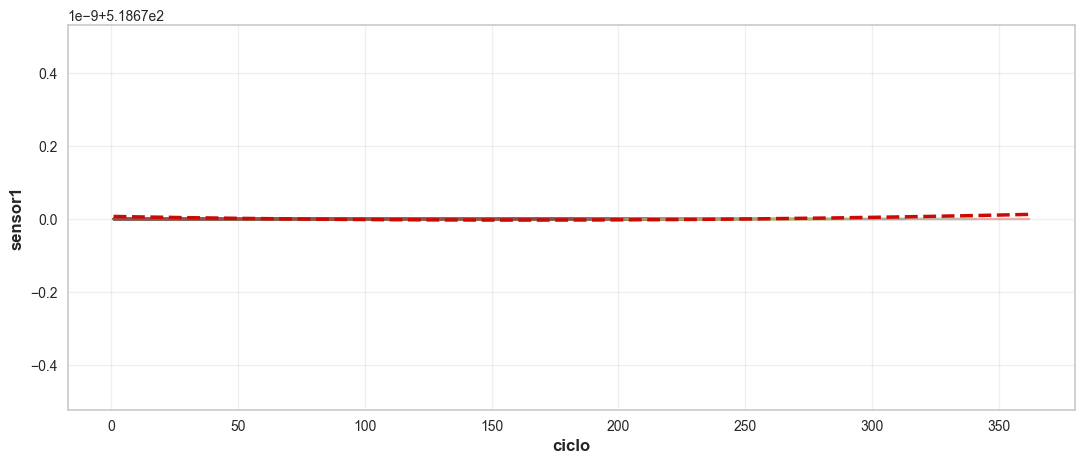

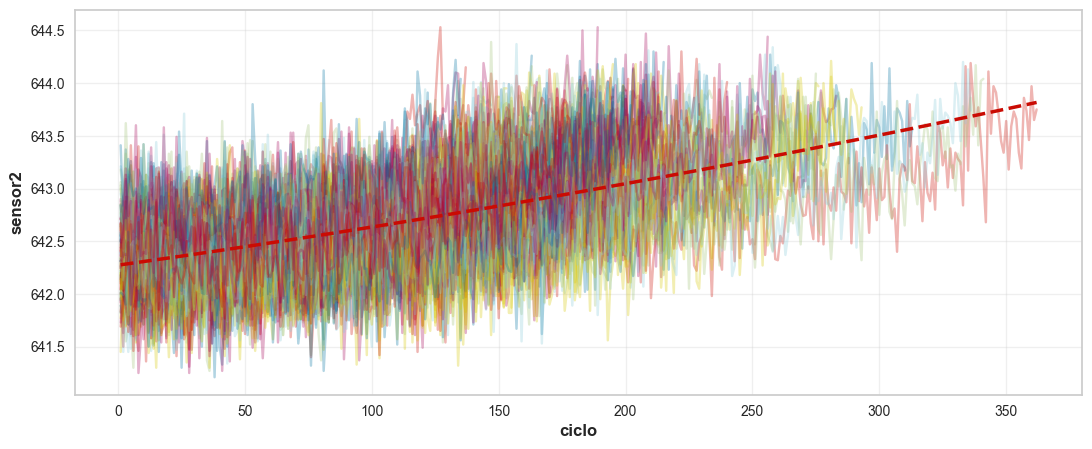

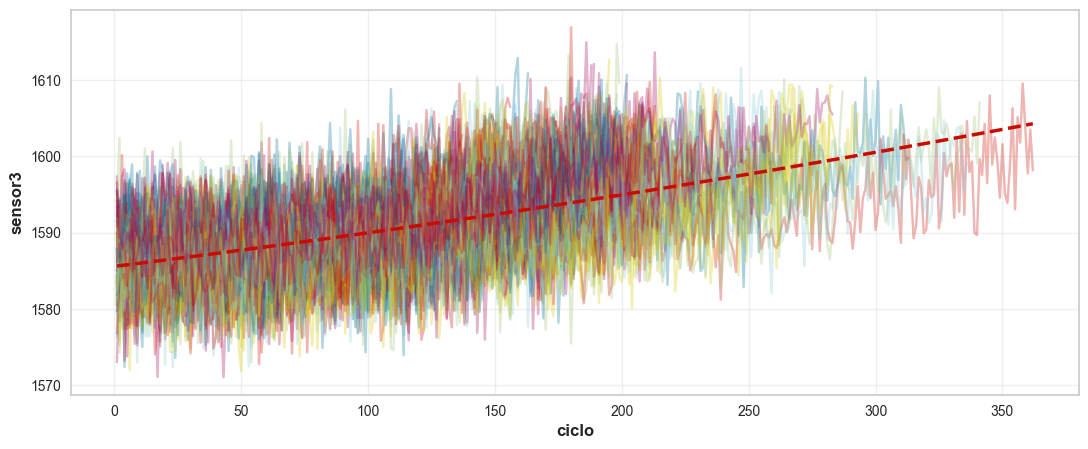

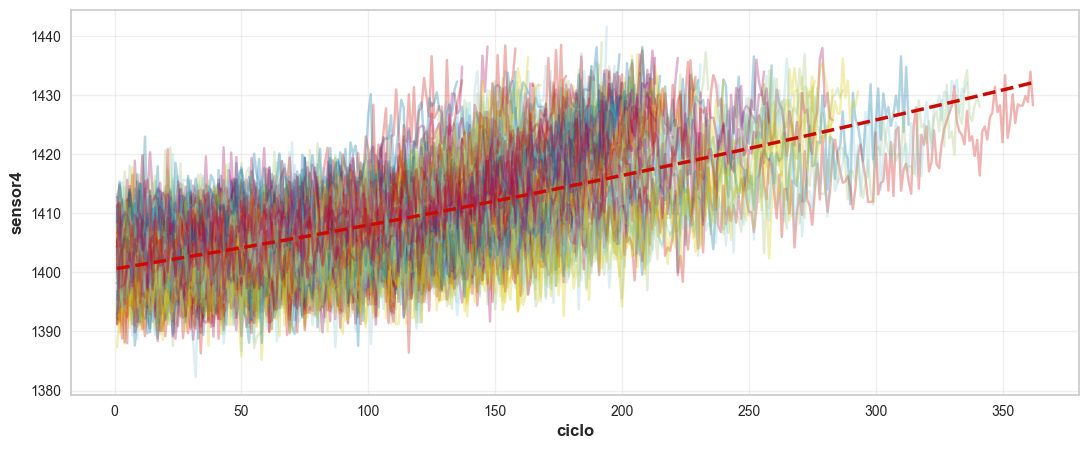

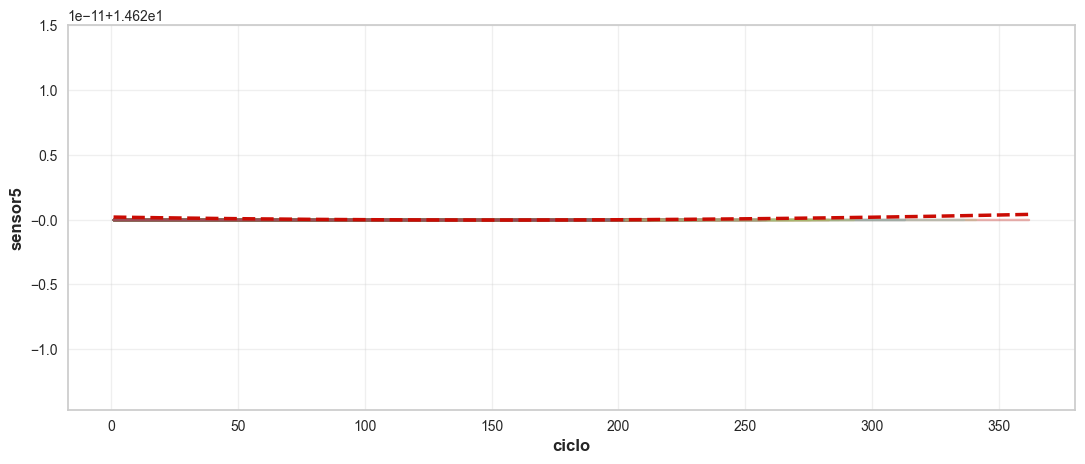

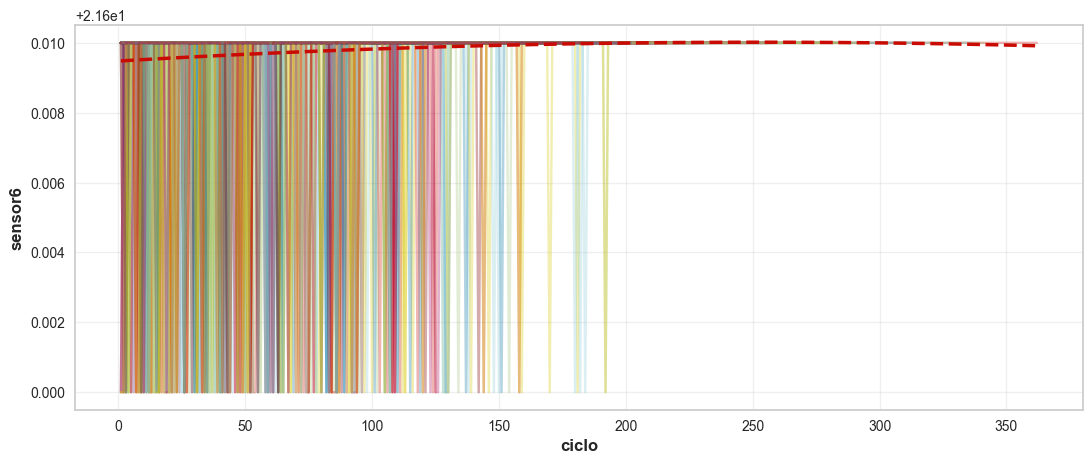

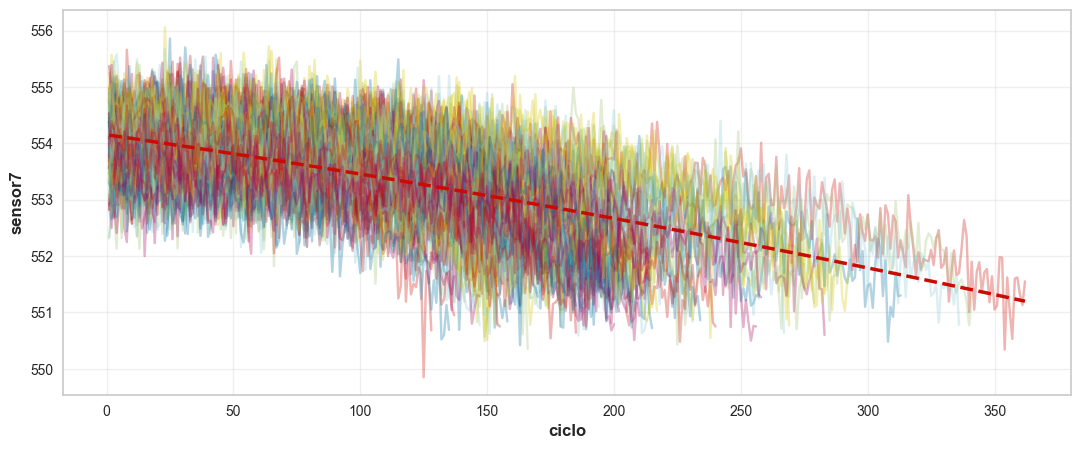

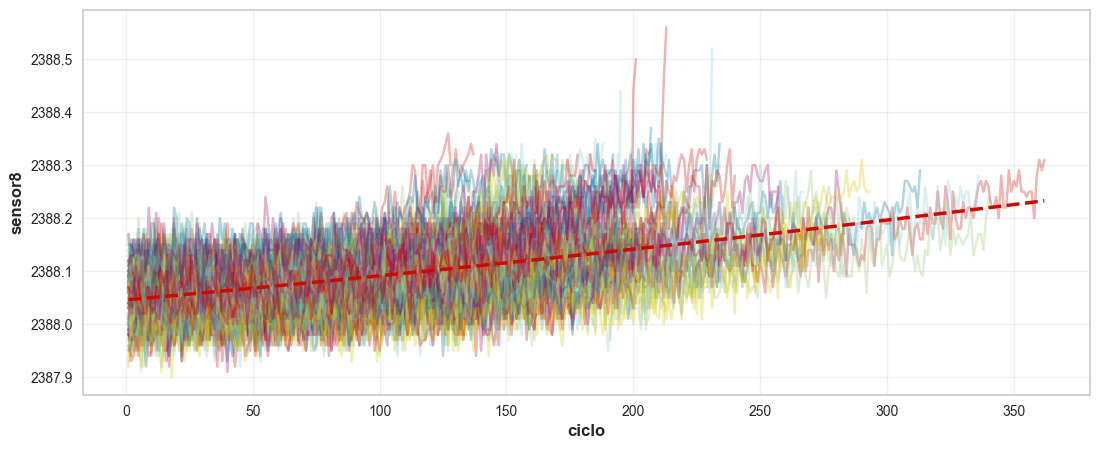

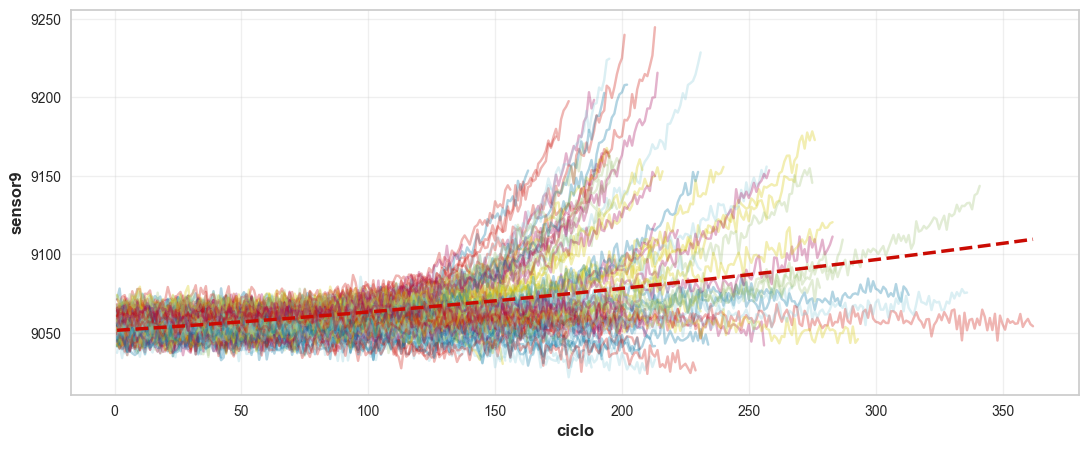

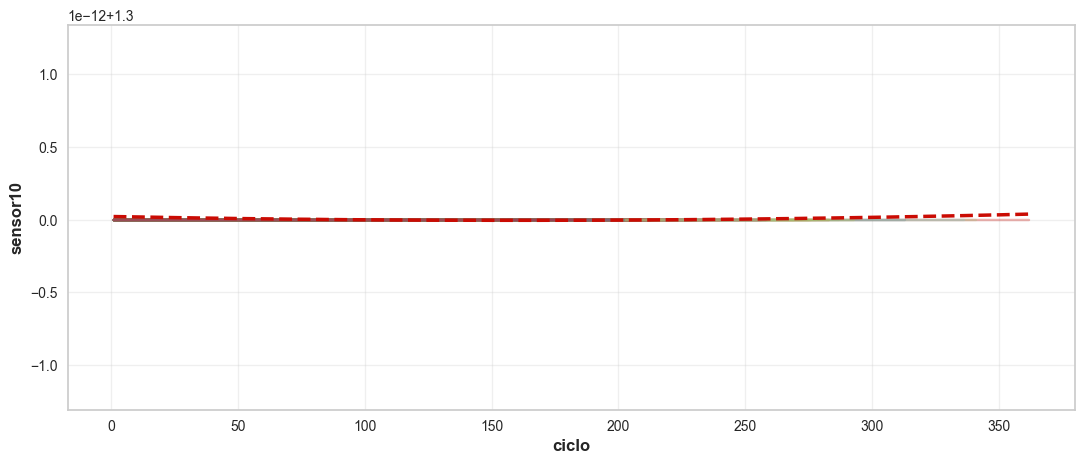

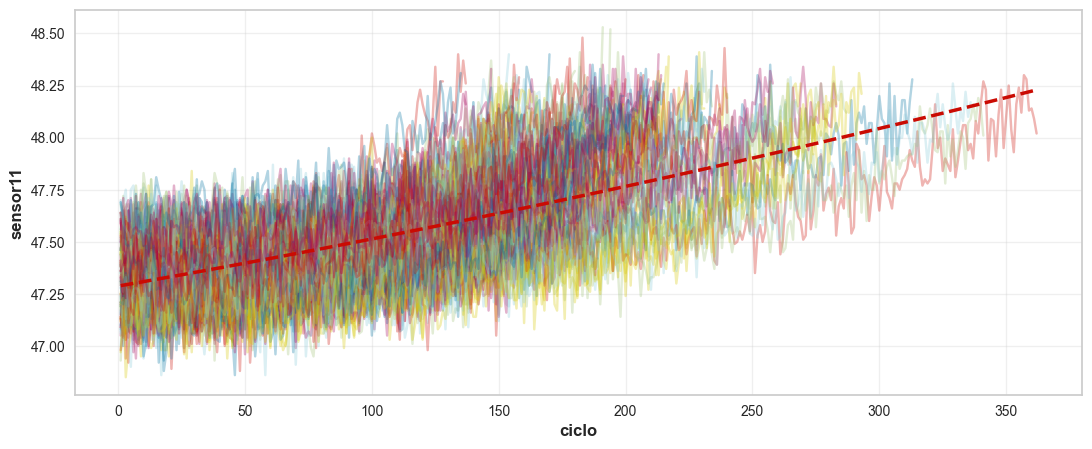

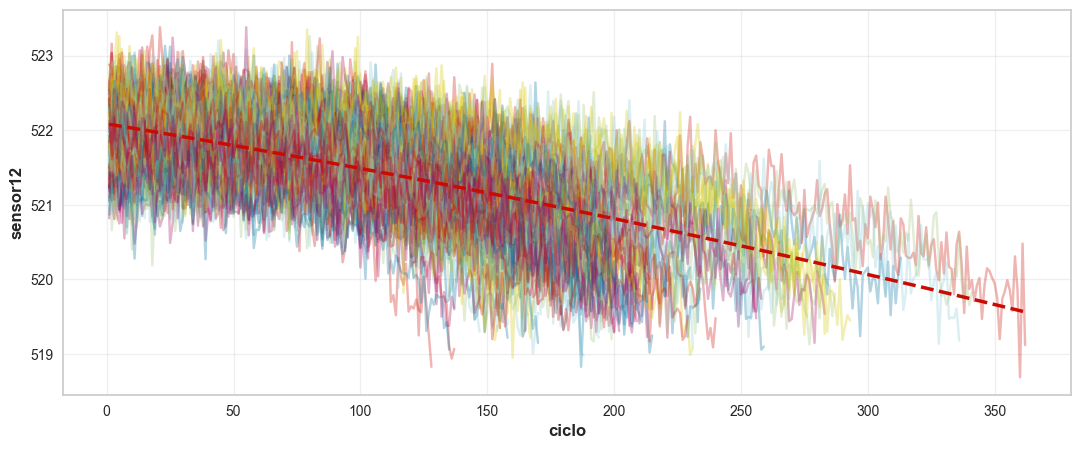

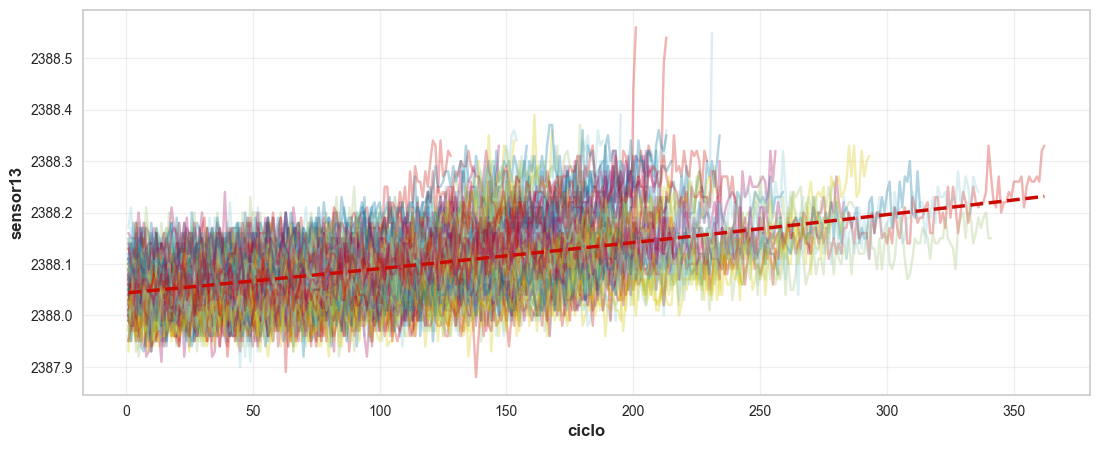

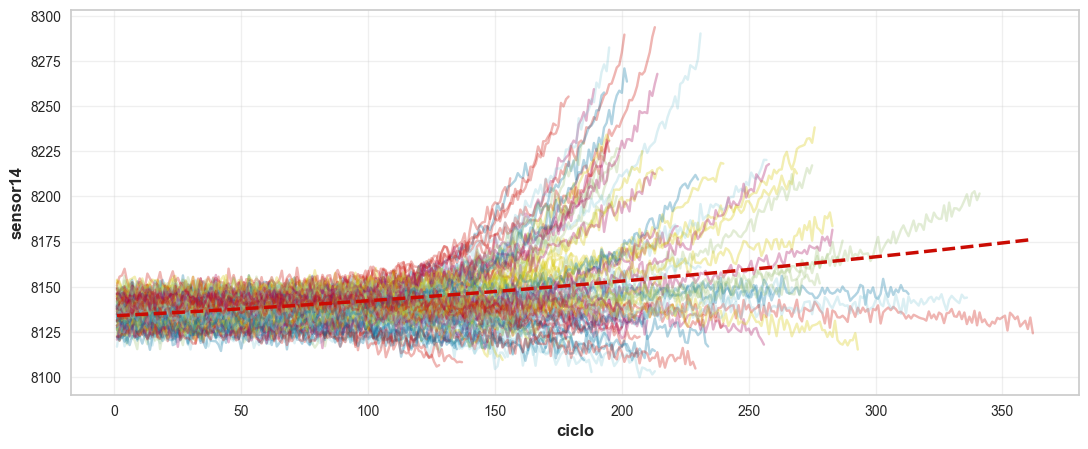

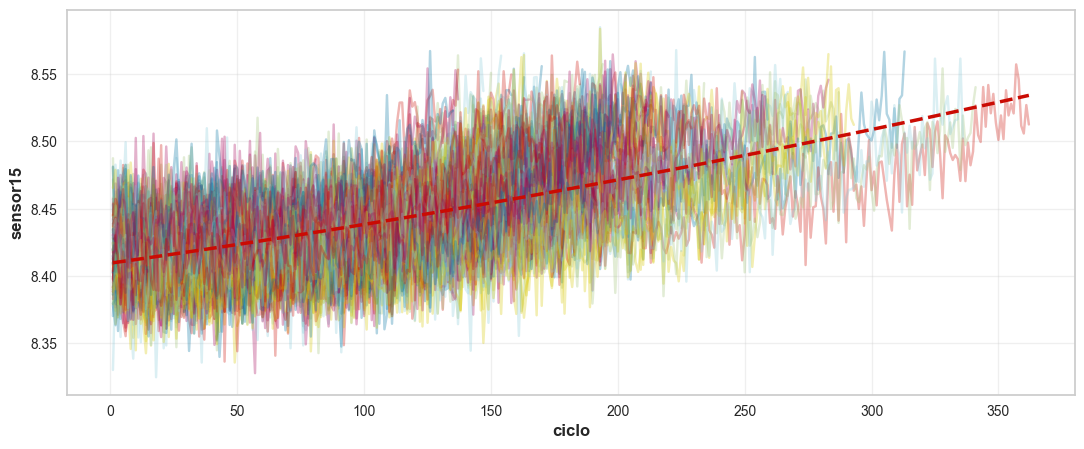

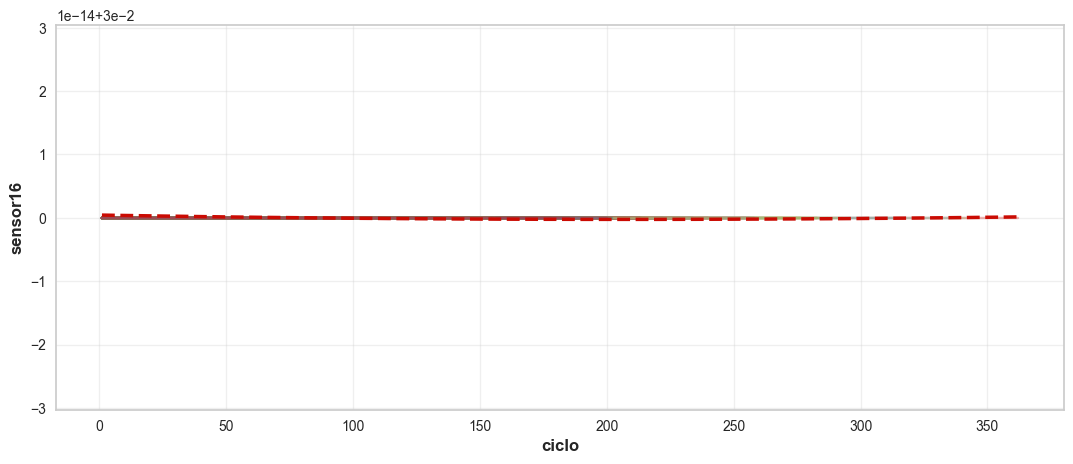

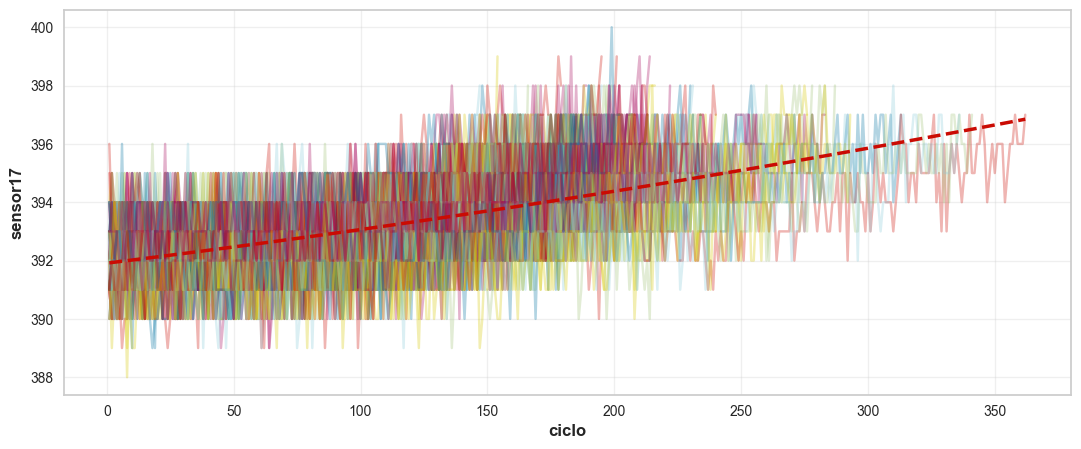

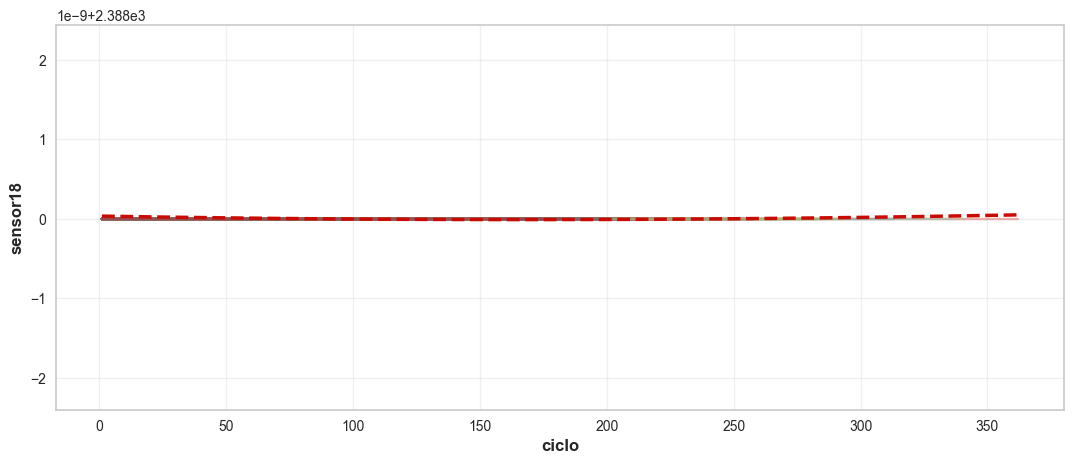

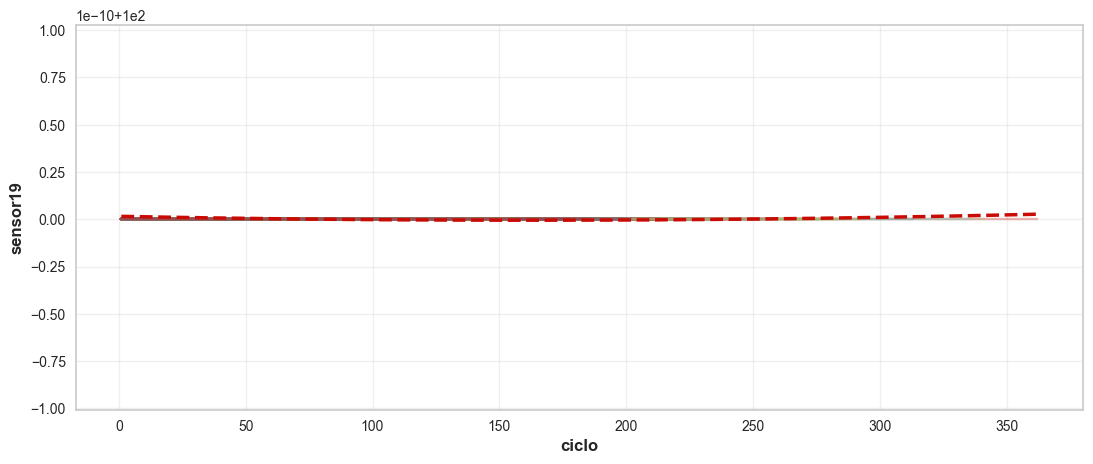

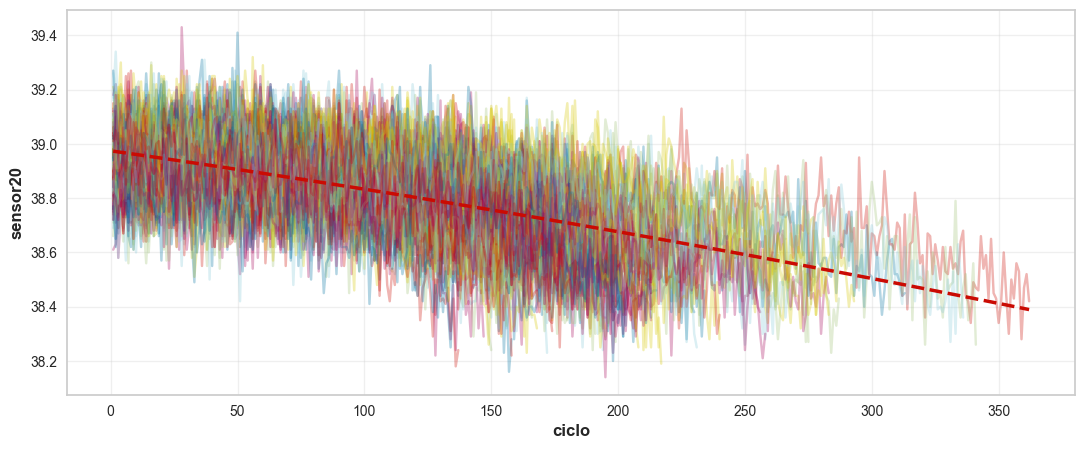

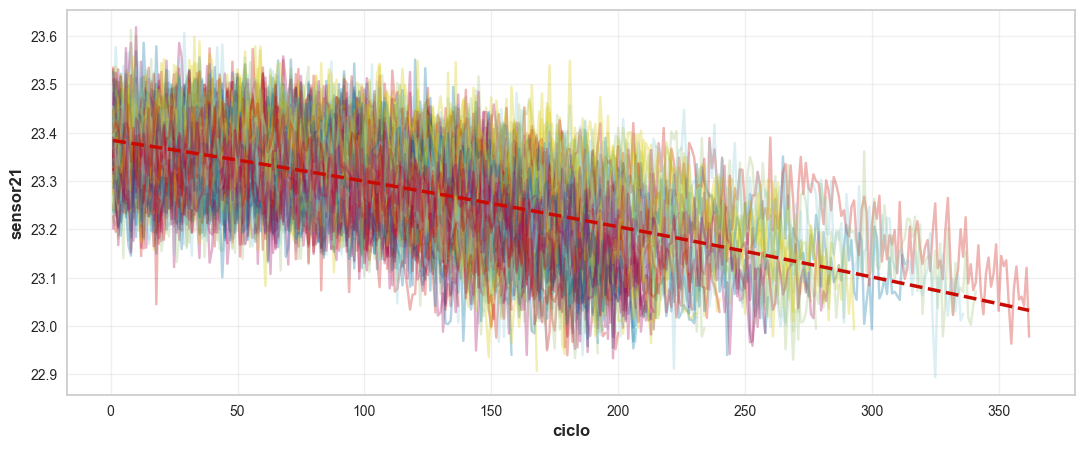

In [8]:
# Generación de gráficos para todos los sensores
etiqueta_x = 'ciclo'

print("📊 Generando visualizaciones para cada sensor...")
print("=" * 60)

for predictor in data.columns[5:]:
    graficar_comportamiento_sensor(data, etiqueta_x, predictor)

**🔍 Análisis de las Tendencias Observadas:**

Los gráficos anteriores revelan el comportamiento de cada sensor desde el inicio de operación hasta el fallo del motor. La línea de tendencia (en rojo) permite identificar tres patrones fundamentales:

**📈 Tendencia Ascendente:**
- Indica que a mayor valor del sensor, el motor se aproxima más al fallo
- **Ejemplos:** `sensor2`, `sensor3`, `sensor4`, `sensor11`, `sensor12`
- **Interpretación:** Estos sensores detectan incrementos en parámetros que sugieren degradación (ej: temperatura, vibraciones)

**📉 Tendencia Descendente:**
- Indica que a menor valor del sensor, el motor se aproxima más al fallo
- **Ejemplos:** `sensor7`, `sensor12`, `sensor15`, `sensor17`
- **Interpretación:** La reducción en estas mediciones puede indicar pérdida de eficiencia o degradación del sistema

**➡️ Tendencia Constante:**
- Indica ausencia de variación significativa desde el inicio hasta el fallo
- **Ejemplos:** `sensor5`, `sensor10`, `sensor16`, `sensor18`, `sensor19`
- **Interpretación:** Estos sensores **NO aportan información predictiva** ya que sus valores no cambian
- **Acción requerida:** Deben ser eliminados en la etapa de preparación de datos para:
  - Reducir la dimensionalidad del problema
  - Mejorar la eficiencia computacional
  - Evitar ruido en el modelo

> 💡 **Conclusión:** Los sensores con tendencia constante serán removidos en la [sección de Preparación de Datos](#preparacion-datos), conservando únicamente aquellos con poder predictivo.

### 3.3 Análisis de la Vida Útil de los Motores

Visualizar la vida útil de cada motor nos permite comprender la distribución de los ciclos antes del fallo.

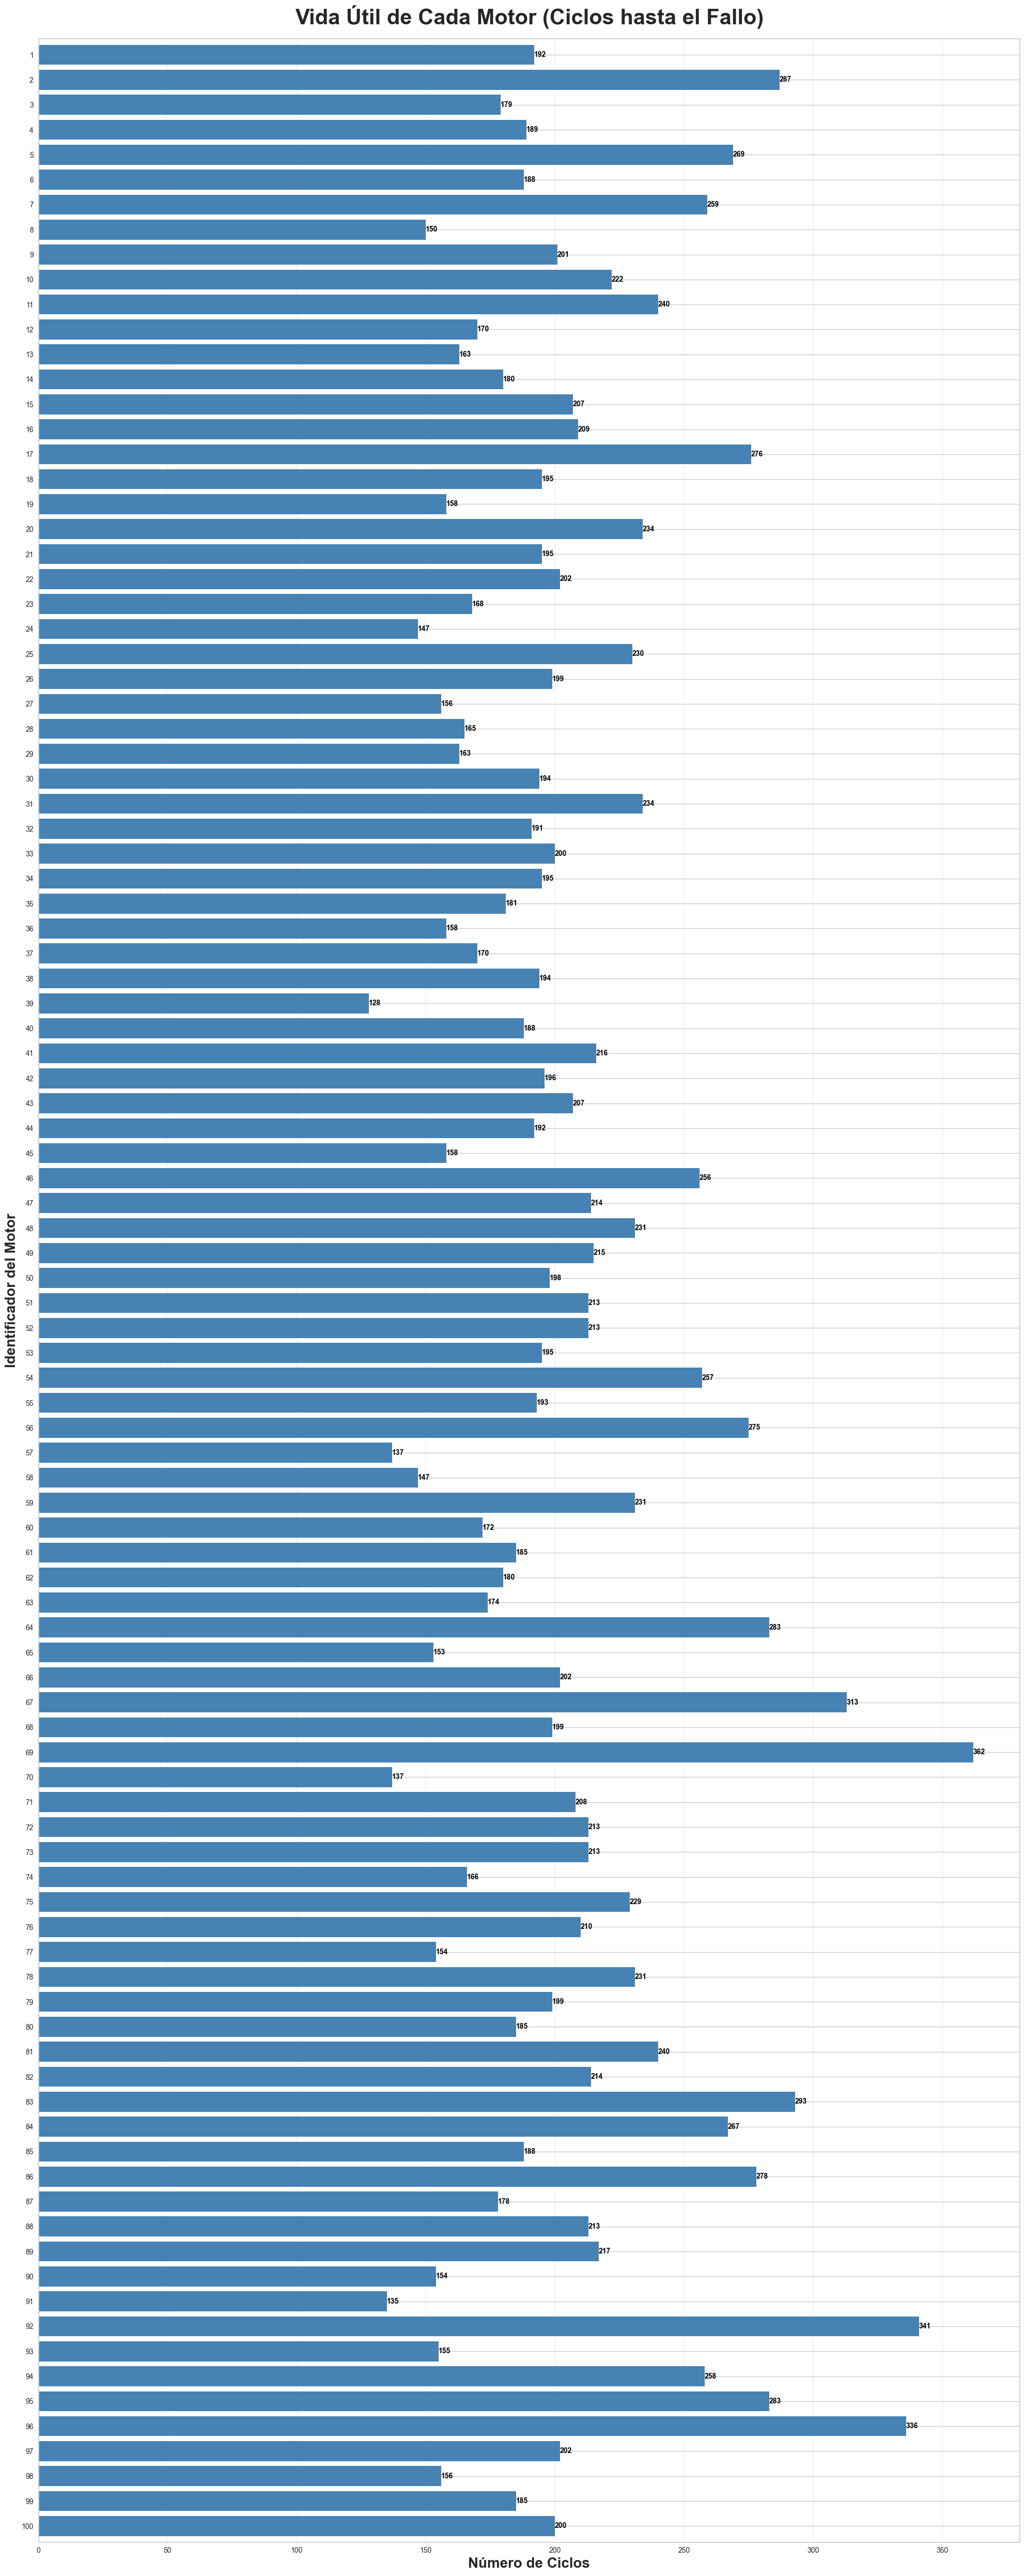

In [9]:
# Cálculo del ciclo máximo (vida útil) para cada motor
ciclos_maximos = data['ciclo'].groupby(data['motor']).max()

# Orden descendente por número de motor
ciclos_maximos = ciclos_maximos.sort_index(ascending=False)

# Configuración de la visualización
plt.figure(figsize=(20, 50))

# Creación del gráfico de barras horizontales
ax = ciclos_maximos.plot(kind='barh', width=0.8, stacked=True, align='center', color='steelblue')

# Adición de etiquetas con valores en cada barra
for container in ax.containers:
    for bar in container:
        ancho = bar.get_width()
        etiqueta = f'{ancho:.0f}'
        ax.text(ancho, bar.get_y() + bar.get_height() / 2, etiqueta,
                va='center', ha='left', fontsize=10, color='black', fontweight='bold')

# Configuración de título y etiquetas
plt.title('Vida Útil de Cada Motor (Ciclos hasta el Fallo)', fontweight='bold', size=30, pad=20)
plt.xlabel('Número de Ciclos', fontweight='bold', size=20)
plt.ylabel('Identificador del Motor', fontweight='bold', size=20)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**💡 Interpretación:**

El gráfico de barras muestra que cada motor tiene una vida útil diferente antes de alcanzar el fallo. Para obtener una perspectiva más detallada sobre la distribución de estas vidas útiles, procederemos a analizar la [distribución estadística](#distribucion-vida-util).

<a name="preparacion-datos"></a>

---

## 4. Preparación y Transformación de Datos

**Resumen de la Sección**
<hr style="border: 1px solid #ddd;">

Esta fase constituye el proceso de limpieza y transformación de datos para generar un conjunto de datos refinado, listo para ser utilizado en algoritmos de Machine Learning.

**Procesos Principales**
<hr style="border: 1px solid #ddd;">

Las transformaciones a realizar incluyen:

- 🧹 **Limpieza de datos** (eliminación de valores NaN y missing values)
- 🎯 **Selección de características** (feature selection)
- 🏷️ **Creación de variables objetivo** (labeling)
- 🔄 **Transformación de formatos** según requerimientos del modelo
- ✂️ **Partición del dataset** (train/test split)
- ⚖️ **Balanceo de clases** mediante técnicas de sampling
- 📏 **Normalización** para homogeneizar escalas entre variables

**Objetivos de la Preparación**
<hr style="border: 1px solid #ddd;">

El propósito fundamental es garantizar que los datos procesados sean:

- ✅ **Precisos y consistentes**
- ✅ **Completos** (sin valores faltantes)
- ✅ **Numéricos** (los algoritmos ML no procesan texto directamente)
- ✅ **Eficientes** (sin variables irrelevantes que aumenten la carga computacional)
- ✅ **Significativos** para producir modelos de alta calidad

### 4.1 Detección y Tratamiento de Valores Faltantes

Los valores ausentes pueden comprometer significativamente el rendimiento de los modelos de Machine Learning. Es imperativo identificarlos y tratarlos adecuadamente.

In [10]:
# Verificación de valores nulos en el dataset
conteo_nulos = data.isnull().sum()

print("🔍 ANÁLISIS DE VALORES FALTANTES")
print("=" * 60)
print(conteo_nulos)
print("=" * 60)

if conteo_nulos.sum() == 0:
    print("✅ El dataset está completo: NO se detectaron valores faltantes")
else:
    print(f"⚠️ Se detectaron {conteo_nulos.sum()} valores faltantes")

🔍 ANÁLISIS DE VALORES FALTANTES
motor       0
ciclo       0
config1     0
config2     0
config3     0
sensor1     0
sensor2     0
sensor3     0
sensor4     0
sensor5     0
sensor6     0
sensor7     0
sensor8     0
sensor9     0
sensor10    0
sensor11    0
sensor12    0
sensor13    0
sensor14    0
sensor15    0
sensor16    0
sensor17    0
sensor18    0
sensor19    0
sensor20    0
sensor21    0
dtype: int64
✅ El dataset está completo: NO se detectaron valores faltantes


**💡 Interpretación:**

El análisis confirma que el dataset está **completamente íntegro**, sin presencia de valores faltantes (NaN). Por lo tanto, **no es necesario** aplicar técnicas de imputación o eliminación de registros incompletos.

In [11]:
# Análisis estadístico descriptivo del dataset
estadisticas_descriptivas = data.describe().transpose()

print("📊 ESTADÍSTICAS DESCRIPTIVAS DEL DATASET")
print("=" * 80)
estadisticas_descriptivas

📊 ESTADÍSTICAS DESCRIPTIVAS DEL DATASET


,count,mean,std,min,25%,50%,75%,max
motor,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
ciclo,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
config1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
config2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
config3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor5,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200


**💡 Interpretación:**

Las estadísticas descriptivas proporcionan información valiosa:

- **count:** Número de observaciones válidas
- **mean:** Valor promedio de cada variable
- **std:** Desviación estándar (dispersión de los datos)
- **min/max:** Valores mínimo y máximo observados
- **25%, 50%, 75%:** Cuartiles de la distribución

**🔍 Hallazgo Importante:** Varias variables presentan valores idénticos de mínimo y máximo, lo que indica que son **constantes** (sin variabilidad). Estas variables no aportan información predictiva y deben ser eliminadas para optimizar el modelo.

### 4.2 Eliminación de Variables Constantes

Las variables con valores constantes no contribuyen al poder predictivo del modelo y aumentan innecesariamente la complejidad computacional.

In [12]:
def eliminar_columnas_constantes(dataframe):
    '''
    Función para identificar y eliminar columnas con valores constantes.
    
    Propósito:
        - Detectar variables que no varían en todo el dataset
        - Una variable se considera constante si min(columna) == max(columna)
        - Eliminar estas variables para reducir dimensionalidad y mejorar eficiencia
    
    Parámetros:
        dataframe -> DataFrame de pandas a analizar
    
    Retorna:
        dataframe -> DataFrame limpio sin columnas constantes
    '''

    # Lista para almacenar nombres de columnas constantes
    columnas_constantes = []

    # Iteración sobre todas las columnas
    for col in dataframe.columns:
        valor_min = dataframe[col].min()
        valor_max = dataframe[col].max()

        # Si min == max, la columna es constante
        if valor_min == valor_max:
            columnas_constantes.append(col)

    # Información sobre las columnas eliminadas
    if columnas_constantes:
        print(f"🗑️ Columnas constantes detectadas: {columnas_constantes}")
        print(f"📉 Se eliminarán {len(columnas_constantes)} variables")
    
    # Eliminación de columnas constantes
    dataframe.drop(columns=columnas_constantes, inplace=True)

    return dataframe

In [13]:
# Aplicación de la función para eliminar variables constantes
print("=" * 70)
print("PROCESO DE ELIMINACIÓN DE VARIABLES CONSTANTES")
print("=" * 70)

dimensiones_antes = data.shape
data = eliminar_columnas_constantes(data)
dimensiones_despues = data.shape

print("=" * 70)
print(f"📊 Dimensiones antes:  {dimensiones_antes[0]:,} filas × {dimensiones_antes[1]} columnas")
print(f"📊 Dimensiones después: {dimensiones_despues[0]:,} filas × {dimensiones_despues[1]} columnas")
print(f"✅ Variables eliminadas: {dimensiones_antes[1] - dimensiones_despues[1]}")
print("=" * 70)

# Visualización del dataset resultante
data

PROCESO DE ELIMINACIÓN DE VARIABLES CONSTANTES
🗑️ Columnas constantes detectadas: ['config3', 'sensor1', 'sensor5', 'sensor10', 'sensor16', 'sensor18', 'sensor19']
📉 Se eliminarán 7 variables
📊 Dimensiones antes:  20,631 filas × 26 columnas
📊 Dimensiones después: 20,631 filas × 19 columnas
✅ Variables eliminadas: 7


,motor,ciclo,config1,config2,sensor2,sensor3,sensor4,sensor6,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,643.49,1597.98,1428.63,21.61,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735
20627,100,197,-0.0016,-0.0005,643.54,1604.50,1433.58,21.61,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594
20628,100,198,0.0004,0.0000,643.42,1602.46,1428.18,21.61,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333
20629,100,199,-0.0011,0.0003,643.23,1605.26,1426.53,21.61,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640


**💡 Interpretación:**

Después del proceso de limpieza, el dataset se redujo de **26 variables** a **19 variables**, eliminando 7 columnas constantes que no aportaban valor predictivo. Esta reducción mejorará significativamente:

- ⚡ La velocidad de entrenamiento del modelo
- 💾 El uso de memoria
- 🎯 La interpretabilidad del modelo
- 📈 Potencialmente, el rendimiento predictivo

<a name="distribucion-vida-util"></a>

### 4.3 Análisis de Distribución de Vida Útil

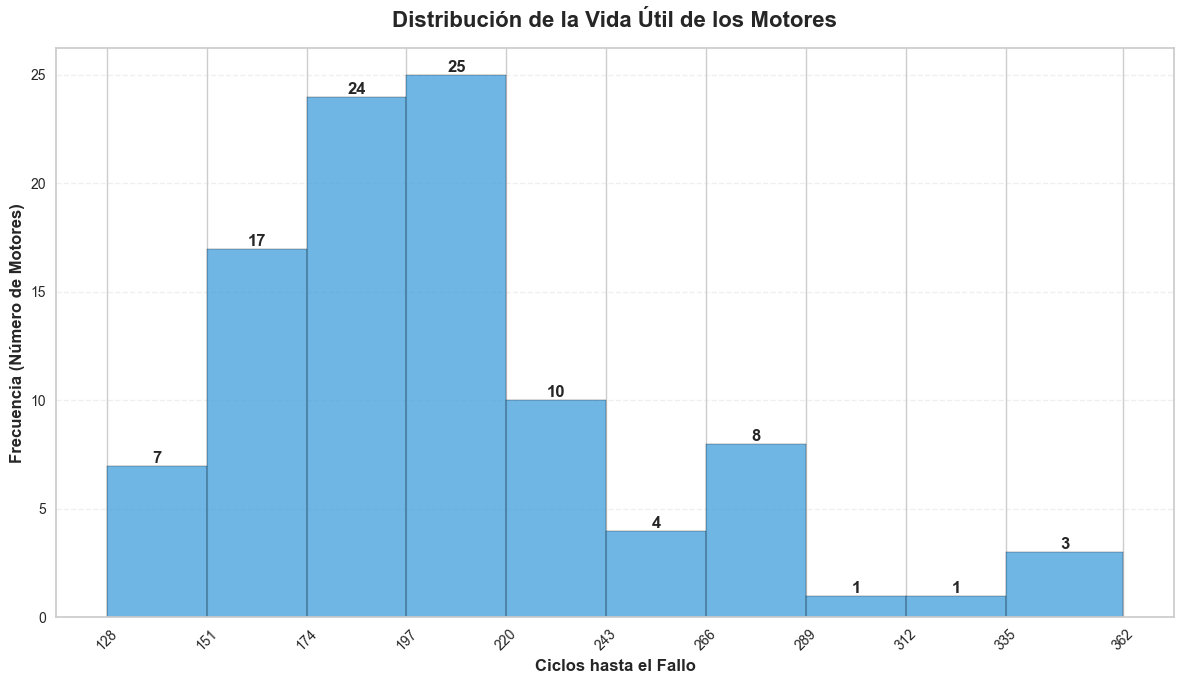

📊 ESTADÍSTICAS DE VIDA ÚTIL
Ciclos mínimos: 358 ciclos
Ciclos máximos: 362 ciclos
Promedio: 206.3 ciclos
Mediana: 199.0 ciclos


In [14]:
# Construcción del histograma de ciclos máximos
df_ciclos_max = data[['motor', 'ciclo']].groupby('motor').max().reset_index()

# Configuración de la figura
plt.figure(figsize=(12, 7))

# Cálculo de parámetros para los bins
numero_bins = 10
valor_maximo = df_ciclos_max['ciclo'].max()
valor_minimo = df_ciclos_max['ciclo'].min()
ancho_bin = round((valor_maximo - valor_minimo) / numero_bins)
lista_bins = []

# Generación de la lista de bins
for i in range(numero_bins):
    lista_bins.append(valor_minimo)
    valor_minimo += ancho_bin
    
    if i + 1 == numero_bins:
        lista_bins.append(valor_maximo)

# Creación del histograma
valores, bins, barras = plt.hist(df_ciclos_max['ciclo'], bins=lista_bins, 
                                  color='#3498db', edgecolor='black', alpha=0.7)
plt.xticks(bins, rotation=45)

# Configuración de etiquetas y título
plt.title("Distribución de la Vida Útil de los Motores", fontweight='bold', size=16, pad=15)
plt.xlabel('Ciclos hasta el Fallo', fontweight='bold', size=12)
plt.ylabel('Frecuencia (Número de Motores)', fontweight='bold', size=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Adición de etiquetas en las barras
plt.bar_label(barras, fontweight='bold')

plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print("=" * 60)
print("📊 ESTADÍSTICAS DE VIDA ÚTIL")
print("=" * 60)
print(f"Ciclos mínimos: {valor_minimo} ciclos")
print(f"Ciclos máximos: {valor_maximo} ciclos")
print(f"Promedio: {df_ciclos_max['ciclo'].mean():.1f} ciclos")
print(f"Mediana: {df_ciclos_max['ciclo'].median():.1f} ciclos")
print("=" * 60)

**💡 Interpretación:**

El histograma revela que:

- **Vida útil mínima:** 128 ciclos
- **Vida útil máxima:** 362 ciclos  
- **Asimetría:** La distribución muestra sesgo hacia la izquierda (*left-skewed*)
- **Concentración:** La mayoría de los motores tienen una vida útil entre **128-220 ciclos**

Esta información es valiosa para establecer umbrales de alerta temprana en el sistema de mantenimiento predictivo.

### 4.4 Creación de Etiquetas (Labeling)

La clasificación supervisada requiere etiquetas que indiquen la clase de cada observación. Dado que nuestro dataset original no incluye estas etiquetas, debemos crearlas basándonos en un criterio técnico.

In [15]:
def asignar_etiquetas(data, umbral):
    '''
    Función para asignar etiquetas de clasificación al dataset.
    
    Estrategia de Etiquetado:
        - Etiqueta 0: Motor en condición NORMAL
        - Etiqueta 1: Motor en condición de FALLO INMINENTE
    
    Parámetros:
        data -> DataFrame con los datos del motor
        umbral -> Número de ciclos antes del fallo para activar alerta
    
    Lógica:
        Para cada motor, si el ciclo actual es mayor que (ciclo_máximo - umbral),
        se etiqueta como fallo inminente (1), de lo contrario como normal (0).
    
    Retorna:
        data -> DataFrame con columna 'estado' agregada
    '''

    for i in range(1, 101):
        # Identificar el ciclo máximo (fallo) de cada motor
        ciclo_maximo = data.loc[(data['motor'] == i), 'ciclo'].max()

        # Calcular el punto de inicio de la alerta
        inicio_alerta = ciclo_maximo - umbral

        # Asignar etiqueta 1 (fallo inminente) a los últimos ciclos
        data.loc[(data['motor'] == i) & (data['ciclo'] > inicio_alerta), 'estado'] = 1

    # Asignar etiqueta 0 (normal) al resto
    data['estado'].fillna(0, inplace=True)

    return data

In [16]:
# Definición del umbral para alerta temprana
umbral = 20

print("=" * 70)
print("🏷️  PROCESO DE ETIQUETADO DE DATOS")
print("=" * 70)
print(f"📍 Umbral configurado: {umbral} ciclos antes del fallo")
print("📍 Estrategia: Alertar {0} ciclos antes del fallo real".format(umbral))
print("=" * 70)

# Aplicación de la función de etiquetado
data = asignar_etiquetas(data, umbral)

print("✅ Etiquetado completado exitosamente")
print("=" * 70)

# Visualización del dataset etiquetado
data

🏷️  PROCESO DE ETIQUETADO DE DATOS
📍 Umbral configurado: 20 ciclos antes del fallo
📍 Estrategia: Alertar 20 ciclos antes del fallo real
✅ Etiquetado completado exitosamente


,motor,ciclo,config1,config2,sensor2,sensor3,sensor4,sensor6,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21,estado
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,0.0
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,0.0
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,0.0
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,0.0
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,643.49,1597.98,1428.63,21.61,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735,1.0
20627,100,197,-0.0016,-0.0005,643.54,1604.50,1433.58,21.61,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594,1.0
20628,100,198,0.0004,0.0000,643.42,1602.46,1428.18,21.61,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333,1.0
20629,100,199,-0.0011,0.0003,643.23,1605.26,1426.53,21.61,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640,1.0


**💡 Interpretación del Umbral:**

La estrategia de etiquetado utiliza un **umbral de 20 ciclos** como ventana de alerta temprana. Esto significa:

**Ejemplo práctico:**
- Si un motor tiene una vida útil de 150 ciclos
- Los ciclos 1-130 se etiquetan como **NORMAL** (estado = 0)
- Los ciclos 131-150 se etiquetan como **FALLO INMINENTE** (estado = 1)

**Justificación técnica:**

1. **Enfoque predictivo vs. reactivo:** No esperamos el fallo real, sino que alertamos con anticipación
2. **Ventana de intervención:** Proporciona 20 ciclos para programar mantenimiento preventivo
3. **Flexibilidad:** El umbral puede ajustarse según necesidades operacionales específicas
4. **Balance riesgo-costo:** 20 ciclos ofrece suficiente margen sin generar alertas excesivamente anticipadas

> ⚙️ **Nota metodológica:** El valor de 20 ciclos es configurable y puede modificarse según los requerimientos del usuario, balanceando entre anticipación y precisión.

📊 DISTRIBUCIÓN DE CLASES
Clase 0 (Normal):         18,631 observaciones (90.3%)
Clase 1 (Fallo Inminente): 2,000 observaciones (9.7%)
Ratio de desbalance:       9.32:1


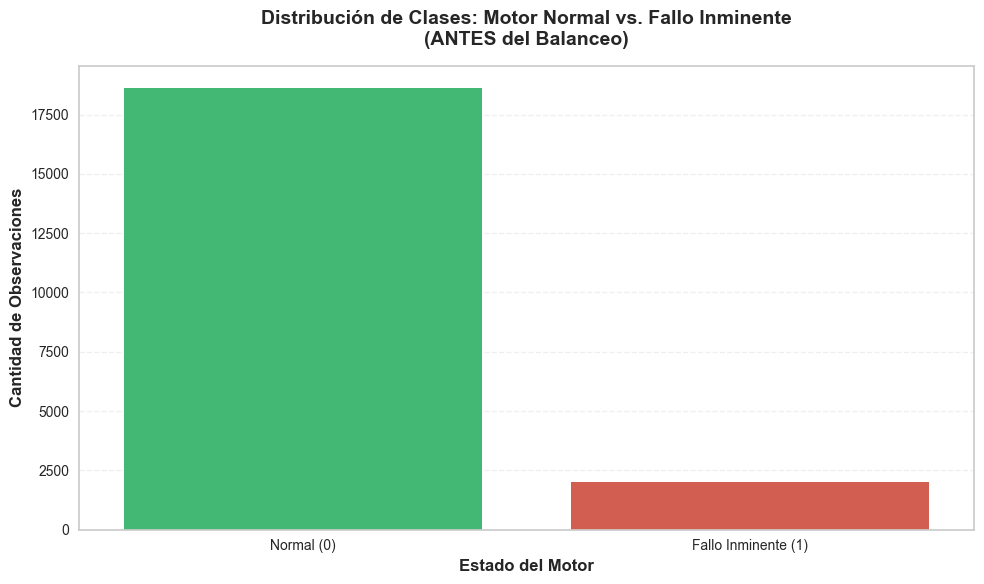

In [17]:
# Análisis de la proporción de clases
plt.figure(figsize=(10, 6))
sns.countplot(x='estado', hue='estado', data=data, palette=['#2ecc71', '#e74c3c'], legend=False)
plt.title("Distribución de Clases: Motor Normal vs. Fallo Inminente\n(ANTES del Balanceo)", 
          fontweight='bold', size=14, pad=15)
plt.xlabel('Estado del Motor', fontweight='bold', size=12)
plt.ylabel('Cantidad de Observaciones', fontweight='bold', size=12)
plt.xticks([0, 1], ['Normal (0)', 'Fallo Inminente (1)'])
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Estadísticas de distribución
conteo_clases = data['estado'].value_counts()
print("=" * 60)
print("📊 DISTRIBUCIÓN DE CLASES")
print("=" * 60)
print(f"Clase 0 (Normal):         {conteo_clases[0]:,} observaciones ({conteo_clases[0]/len(data)*100:.1f}%)")
print(f"Clase 1 (Fallo Inminente): {conteo_clases[1]:,} observaciones ({conteo_clases[1]/len(data)*100:.1f}%)")
print(f"Ratio de desbalance:       {conteo_clases[0]/conteo_clases[1]:.2f}:1")
print("=" * 60)

plt.tight_layout()
plt.show()

**💡 Interpretación del Desbalance:**

El análisis revela un **desbalance significativo** entre clases:

- **Clase mayoritaria (Normal):** 18,631 observaciones (90.3%)
- **Clase minoritaria (Fallo):** 2,000 observaciones (9.7%)

Esta distribución desbalanceada es representativa de escenarios reales donde fallos son eventos raros.

### 4.5 Selección de Características (Feature Selection)

No todas las variables tienen el mismo poder predictivo. La selección de características permite identificar y retener únicamente aquellas variables que contribuyen significativamente a la predicción, reduciendo la dimensionalidad y mejorando la eficiencia del modelo.

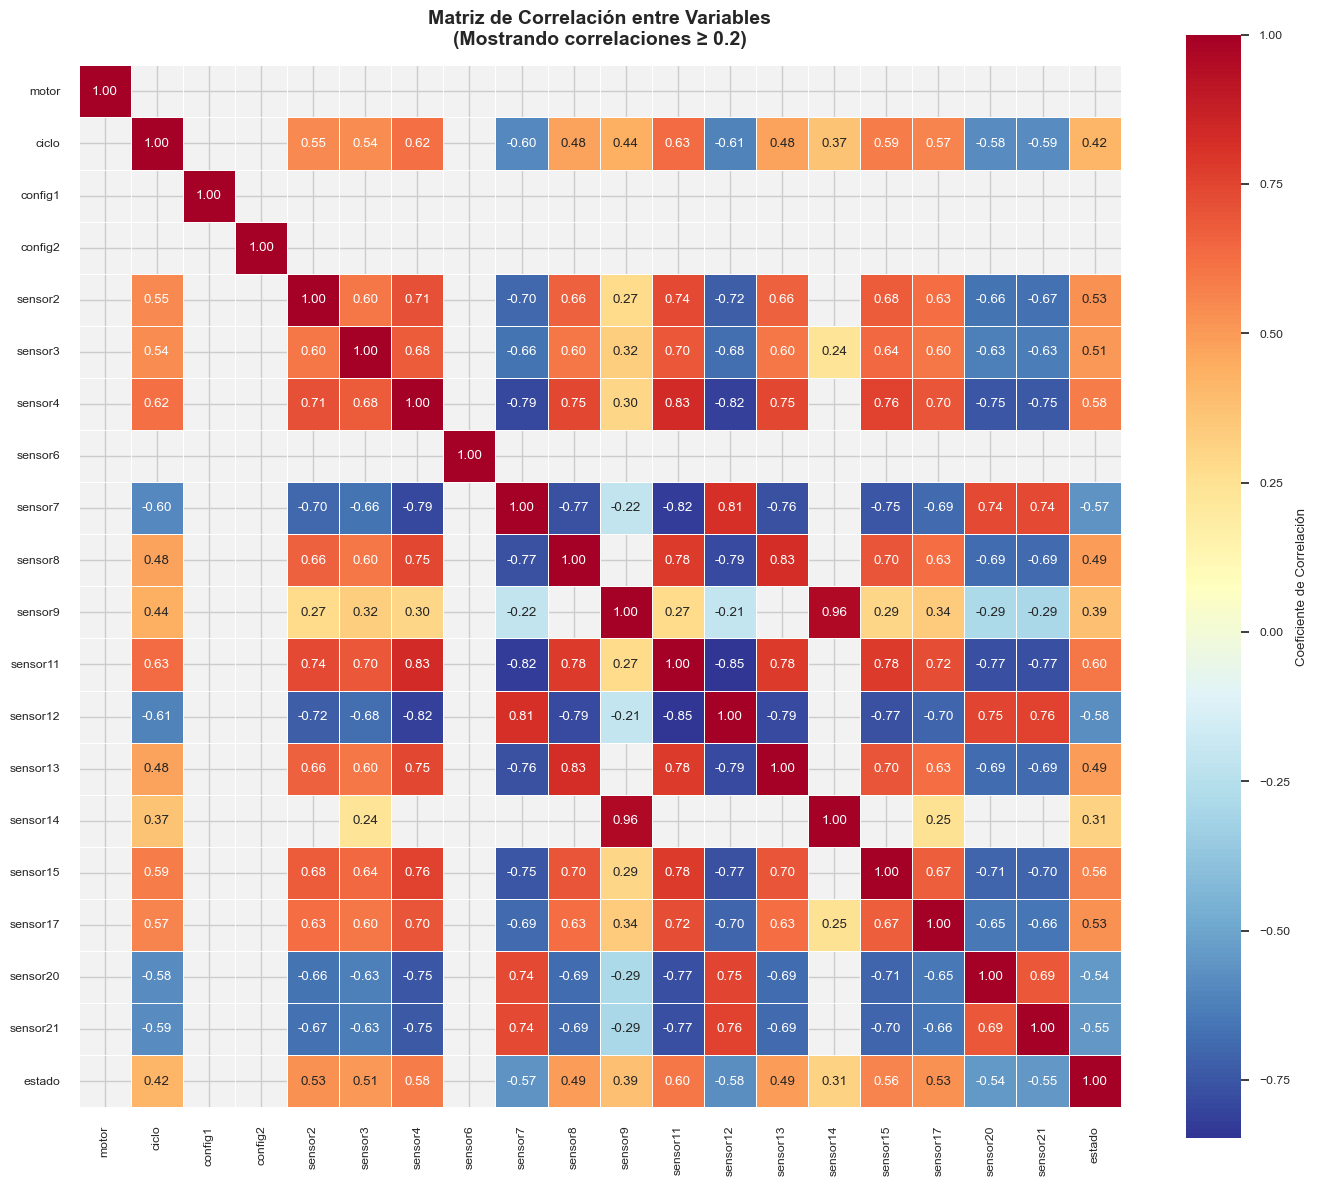

In [18]:
# Mapa de calor para análisis de correlaciones
umbral_correlacion = 0.2

plt.figure(figsize=(14, 12))
sns.set(font_scale=0.8)
sns.set_style("whitegrid", {"axes.facecolor": ".95"})

# Cálculo de la matriz de correlación
matriz_correlacion = data.corr()

# Máscara para mostrar solo correlaciones significativas
mascara = matriz_correlacion.where((abs(matriz_correlacion) >= umbral_correlacion)).isna()

# Creación del mapa de calor
sns.heatmap(matriz_correlacion,
            cmap='RdYlBu_r',
            annot=True,
            fmt='.2f',
            mask=mascara,
            linewidths=0.5,
            linecolor='white',
            square=True,
            cbar_kws={'label': 'Coeficiente de Correlación'})

plt.title(f'Matriz de Correlación entre Variables\n(Mostrando correlaciones ≥ {umbral_correlacion})', 
          fontweight='bold', size=14, pad=15)
plt.tight_layout()
plt.show()

**🔍 Interpretación de la Matriz de Correlación:**

El mapa de calor visualiza las relaciones lineales entre variables, mostrando únicamente correlaciones con valor absoluto ≥ 0.2

**📊 Conceptos clave:**

| Valor de Correlación | Interpretación | Relación |
|---------------------|----------------|----------|
| **+1.0** | Correlación perfecta positiva | Ambas variables aumentan juntas |
| **+0.7 a +0.9** | Correlación fuerte positiva | Fuerte relación directa |
| **+0.4 a +0.6** | Correlación moderada positiva | Relación directa moderada |
| **+0.2 a +0.4** | Correlación débil positiva | Relación directa débil |
| **0.0** | Sin correlación | Variables independientes |
| **-0.2 a -0.4** | Correlación débil negativa | Relación inversa débil |
| **-0.4 a -0.6** | Correlación moderada negativa | Relación inversa moderada |
| **-0.7 a -0.9** | Correlación fuerte negativa | Fuerte relación inversa |
| **-1.0** | Correlación perfecta negativa | Relación inversa perfecta |

**Ejemplo práctico del dataset:**
- Si `sensor2` y `sensor7` tienen correlación de **-0.7**, significa que cuando sensor2 aumenta, sensor7 tiende a disminuir proporcionalmente.

> 💡 **Objetivo:** Identificar las variables con mayor correlación con `estado` para retenerlas en el modelo.

In [19]:
# Identificación de variables relevantes basadas en correlación con la variable objetivo
correlacion_con_objetivo = data.corr()
caracteristicas_relevantes = correlacion_con_objetivo[abs(correlacion_con_objetivo['estado']) >= umbral_correlacion]

print("=" * 70)
print("🎯 CARACTERÍSTICAS RELEVANTES (Correlación ≥ 0.2 con 'estado')")
print("=" * 70)
print(caracteristicas_relevantes['estado'].sort_values(ascending=False))
print("=" * 70)

🎯 CARACTERÍSTICAS RELEVANTES (Correlación ≥ 0.2 con 'estado')
estado      1.000000
sensor11    0.600408
sensor4     0.582934
sensor15    0.561315
sensor2     0.526491
sensor17    0.525363
sensor3     0.508912
sensor8     0.494334
sensor13    0.491833
ciclo       0.418602
sensor9     0.385557
sensor14    0.313872
sensor20   -0.540980
sensor21   -0.547923
sensor7    -0.565367
sensor12   -0.577070
Name: estado, dtype: float64


In [20]:
# Extracción de las características seleccionadas
lista_caracteristicas_relevantes = list(caracteristicas_relevantes.index[1:])

# Filtrado del dataset para retener solo características relevantes
data = data[lista_caracteristicas_relevantes]

print("✅ Selección de características completada")
print("=" * 70)
print(f"📊 Variables retenidas: {len(lista_caracteristicas_relevantes) - 1} predictores + 1 variable objetivo")
print(f"📋 Predictores seleccionados: {', '.join(lista_caracteristicas_relevantes[:-1])}")
print("=" * 70)

# Visualización del dataset filtrado
data

✅ Selección de características completada
📊 Variables retenidas: 14 predictores + 1 variable objetivo
📋 Predictores seleccionados: sensor2, sensor3, sensor4, sensor7, sensor8, sensor9, sensor11, sensor12, sensor13, sensor14, sensor15, sensor17, sensor20, sensor21


,sensor2,sensor3,sensor4,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21,estado
0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,0.0
1,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,0.0
2,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,0.0
3,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,0.0
4,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,643.49,1597.98,1428.63,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735,1.0
20627,643.54,1604.50,1433.58,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594,1.0
20628,643.42,1602.46,1428.18,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333,1.0
20629,643.23,1605.26,1426.53,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640,1.0


**💡 Interpretación:**

Después del proceso de selección de características, hemos reducido el dataset a **14 variables predictoras** más **1 variable objetivo** (`estado`). 

Esta reducción desde las 19 variables iniciales hasta 14 se basa en el criterio de correlación ≥ 0.2 con la variable objetivo, lo que garantiza que:

- ✅ Todas las variables retenidas tienen poder predictivo
- ✅ Se reduce la dimensionalidad del problema
- ✅ Se mejora la eficiencia computacional
- ✅ Se minimiza el riesgo de sobreajuste (overfitting)

### 4.6 Partición del Conjunto de Datos (Train-Test Split)

La división del dataset en conjuntos de entrenamiento y prueba es fundamental para evaluar el desempeño real del modelo en datos no vistos durante el entrenamiento.

In [21]:
# Separación de variables predictoras (X) y variable objetivo (y)
X = data.iloc[:, :-1]  # Todas las columnas excepto la última
y = data.iloc[:, -1:]  # Solo la última columna (estado)

print("=" * 70)
print("🔀 SEPARACIÓN DE VARIABLES")
print("=" * 70)
print(f"📊 Forma de X (predictores): {X.shape}")
print(f"🎯 Forma de y (objetivo):    {y.shape}")
print("=" * 70)

# División del dataset en conjuntos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42,
    stratify=y  # Mantiene la proporción de clases en ambos conjuntos
)

# Conversión de y_train a array 1D para compatibilidad
y_train = y_train.squeeze()

print("\n✅ Partición completada")
print("=" * 70)
print("📚 CONJUNTO DE ENTRENAMIENTO")
print(f"   X_train: {X_train.shape[0]:,} observaciones × {X_train.shape[1]} características")
print(f"   y_train: {y_train.shape[0]:,} etiquetas")
print()
print("🧪 CONJUNTO DE PRUEBA")
print(f"   X_test:  {X_test.shape[0]:,} observaciones × {X_test.shape[1]} características")
print(f"   y_test:  {y_test.shape[0]:,} etiquetas")
print("=" * 70)

🔀 SEPARACIÓN DE VARIABLES
📊 Forma de X (predictores): (20631, 14)
🎯 Forma de y (objetivo):    (20631, 1)

✅ Partición completada
📚 CONJUNTO DE ENTRENAMIENTO
   X_train: 16,504 observaciones × 14 características
   y_train: 16,504 etiquetas

🧪 CONJUNTO DE PRUEBA
   X_test:  4,127 observaciones × 14 características
   y_test:  4,127 etiquetas


In [22]:
# Análisis de la distribución de clases en el conjunto de prueba
print("📊 DISTRIBUCIÓN DE CLASES EN CONJUNTO DE PRUEBA")
print("=" * 70)
print(f"Clase 0 (Normal):          {y_test.value_counts()[0]:,} observaciones")
print(f"Clase 1 (Fallo Inminente): {y_test.value_counts()[1]:,} observaciones")
print("=" * 70)

📊 DISTRIBUCIÓN DE CLASES EN CONJUNTO DE PRUEBA
Clase 0 (Normal):          3,727 observaciones
Clase 1 (Fallo Inminente): 400 observaciones


**💡 Interpretación:**

**Estrategia de Partición 80/20:**
- **80% para entrenamiento:** El modelo aprende patrones de 16,504 observaciones
- **20% para prueba:** Evaluamos el desempeño con 4,127 observaciones no vistas

**¿Por qué esta división?**
- ✅ Proporciona suficientes datos para que el modelo aprenda patrones robustos
- ✅ Mantiene un conjunto de prueba representativo para evaluación confiable
- ✅ Es una práctica estándar en la industria del Machine Learning

**Distribución en test:** La proporción de clases se mantiene similar al dataset original gracias al parámetro `stratify`, garantizando una evaluación justa.

### 4.8 Normalización de Datos (Feature Scaling)

La normalización transforma todas las variables a una escala común, evitando que variables con rangos grandes dominen el proceso de aprendizaje.

In [23]:
# Conversión de X_train a DataFrame para preservar nombres de columnas
X_train = pd.DataFrame(X_train, columns=X.columns)

print("=" * 70)
print("📏 PROCESO DE NORMALIZACIÓN (StandardScaler)")
print("=" * 70)
print("\n📊 Estadísticas ANTES de la normalización:")
print(X_train.describe().loc[['mean', 'std', 'min', 'max']].round(2))

# Inicialización y ajuste del escalador
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Persistencia del escalador para uso en producción
dump(scaler, 'scaler.bin', compress=True)
print("\n💾 Escalador guardado en 'scaler.bin' para futuras predicciones")

# Conversión a DataFrame para visualización
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("\n📊 Estadísticas DESPUÉS de la normalización:")
print(X_train_scaled_df.describe().loc[['mean', 'std', 'min', 'max']].round(2))
print("\n✅ Normalización completada")
print("=" * 70)

# Visualización del dataset normalizado
X_train_scaled_df.head(10)

📏 PROCESO DE NORMALIZACIÓN (StandardScaler)

📊 Estadísticas ANTES de la normalización:
      sensor2  sensor3  sensor4  sensor7  sensor8  sensor9  sensor11  \
mean   642.68  1590.52  1408.95   553.37  2388.10  9065.22     47.54   
std      0.50     6.11     8.98     0.88     0.07    22.05      0.27   
min    641.21  1571.04  1382.25   549.85  2387.91  9024.27     46.85   
max    644.53  1614.72  1438.96   556.06  2388.56  9244.59     48.53   

      sensor12  sensor13  sensor14  sensor15  sensor17  sensor20  sensor21  
mean    521.41   2388.10   8143.74      8.44    393.21     38.82     23.29  
std       0.74      0.07     19.05      0.04      1.55      0.18      0.11  
min     518.69   2387.88   8099.94      8.32    388.00     38.14     22.89  
max     523.38   2388.56   8293.72      8.58    400.00     39.41     23.62  

💾 Escalador guardado en 'scaler.bin' para futuras predicciones

📊 Estadísticas DESPUÉS de la normalización:
      sensor2  sensor3  sensor4  sensor7  sensor8  sensor9

,sensor2,sensor3,sensor4,sensor7,sensor8,sensor9,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21
0,0.635643,0.762083,-0.489423,-0.461481,0.466198,0.062251,0.293658,0.049474,-0.226837,0.109125,0.015354,-0.136218,0.299129,-0.915074
1,-1.062927,-1.027178,-0.751157,1.267491,-0.799908,0.338917,-1.279184,1.012482,-1.198617,0.123826,-0.634892,-0.781864,1.184400,1.024193
2,0.515744,-1.437694,-0.258873,2.069825,-0.518551,-0.005328,-0.342969,0.442816,-0.088011,-0.119785,-1.034634,-0.781864,0.852423,0.678554
3,0.315912,-0.896336,0.315829,-1.139509,1.450947,-1.217213,-0.342969,0.564887,0.744943,-1.331017,0.175250,0.509428,0.299129,0.501587
4,-1.122877,-2.626718,-1.254578,1.470900,-1.643979,-0.688374,-0.680006,1.853419,-1.476268,-0.329270,-0.195177,-1.427509,1.295059,0.826948
5,0.215996,1.123533,0.631024,-1.083007,-0.096516,0.211469,0.480901,0.090165,0.328466,0.040347,0.644280,-0.136218,-2.246025,-0.799861
6,-0.363516,0.580540,0.468414,0.273050,-0.377873,0.317146,-0.417866,0.293617,-0.643314,0.239331,-0.125888,-1.427509,0.686435,-0.615520
7,0.855458,0.843859,1.005249,-0.099866,1.028911,-0.076535,1.042630,-0.520193,0.606118,0.087074,0.535018,-0.136218,-1.028777,-0.146372
8,0.915407,0.029369,-0.598571,-0.325875,0.184841,-0.838953,0.143863,-0.031907,-0.365663,-0.839069,-0.392383,-0.136218,-0.475483,0.704362
9,0.136063,1.269095,0.338104,-0.551885,0.325519,-0.119169,0.218760,-0.899970,1.022595,-0.632210,0.572327,-0.136218,-0.143507,-1.409108


**💡 Interpretación de la Normalización:**

**StandardScaler** transforma cada variable para tener:
- **Media (μ) = 0**
- **Desviación estándar (σ) = 1**

**Fórmula aplicada:**
$$z = \frac{x - \mu}{\sigma}$$

**Beneficios de la normalización:**
- ⚡ Acelera la convergencia de algoritmos de optimización
- 🎯 Evita que variables con valores grandes dominen el modelo
- 📊 Mejora la estabilidad numérica
- 🔄 Facilita la interpretación de la importancia de cada variable

**Observación:** Después de la normalización, todas las variables tienen rangos similares, lo que permite al modelo procesarlas de manera equitativa.

---

## 5. Modelado y Evaluación

**Resumen de la Sección**
<hr style="border: 1px solid #ddd;">

En esta fase se construyen y entrenan el modelo de Machine Learning que aprenderá a clasificar el estado de los motores de acuerdo a sus patrones de comportamiento. 

### 5.1 Modelo de Red Neuronal LSTM (Long Short-Term Memory)

**¿Qué son las Redes LSTM?**

Las **LSTM** son un tipo especial de **Red Neuronal Recurrente (RNN)** diseñadas para aprender de secuencias y series de tiempo. A diferencia de las ANN tradicionales que tratan cada observación de forma independiente, las LSTM pueden "recordar" información de pasos anteriores en la secuencia, lo que es ideal para analizar la degradación progresiva de motores.

**📊 Diferencias clave: ANN vs LSTM:**

| Aspecto | ANN Tradicional | LSTM |
|---------|----------------|------|
| **Tipo de datos** | Datos tabulares independientes | Secuencias temporales |
| **Memoria** | Sin memoria del pasado | Recuerda información previa |
| **Ideal para** | Clasificación estática | Series de tiempo, secuencias |
| **En este proyecto** | Analiza un ciclo aislado | Analiza evolución temporal |

**🧠 Componentes de una celda LSTM:**

| Componente | Función | Analogía |
|------------|---------|----------|
| **Input Gate** | Decide qué información nueva guardar | "¿Qué datos son importantes?" |
| **Forget Gate** | Decide qué información olvidar | "¿Qué datos ya no sirven?" |
| **Output Gate** | Decide qué información usar | "¿Qué datos mostrar ahora?" |
| **Cell State** | Memoria a largo plazo | "Historial completo del motor" |

**🔄 Ventajas para Mantenimiento Predictivo:**

1. **Captura patrones temporales**: Detecta cómo los sensores cambian con el tiempo
2. **Memoria selectiva**: Recuerda solo información relevante del pasado
3. **Detección temprana**: Identifica tendencias de degradación antes del fallo
4. **Robustez**: Maneja secuencias de longitud variable

#### 5.1.1 Preparación de Datos para Secuencias Temporales

Para usar LSTM, necesitamos reorganizar los datos en secuencias. En lugar de usar un solo ciclo por motor, crearemos ventanas de tiempo que muestren la evolución de los sensores.

**CONSIDERACIONES CRÍTICAS PARA EVITAR FUGA DE DATOS:**

1. **Split por Motor (NO por filas aleatorias)**
   - Usamos `GroupShuffleSplit` para separar motores completos entre train/test
   - Esto garantiza que no haya secuencias del mismo motor en ambos conjuntos
   
2. **NO aplicar SMOTE antes de crear secuencias**
   - SMOTE crea datos sintéticos que rompen la continuidad temporal
   - Para LSTM necesitamos secuencias reales y continuas de cada motor
   - El desbalance se manejará con `class_weight` o métricas apropiadas
   
3. **Validación en motores separados**
   - NO usar `validation_split` (mezclaría secuencias del mismo motor)
   - Separar motores manualmente entre train/val usando sus IDs
   - Usar `validation_data` con motores completamente diferentes

In [32]:
def crear_secuencias(X_data, y_data, id_motor_col=0, longitud_secuencia=10):
    '''
    Convierte datos tabulares en secuencias temporales para LSTM.
    
    Cada secuencia contiene 'longitud_secuencia' ciclos consecutivos de un motor,
    y la etiqueta corresponde al último ciclo de la secuencia.
    
    Parámetros:
        X_data: Datos de entrada (incluye columna de ID motor)
        y_data: Etiquetas
        id_motor_col: Índice de la columna ID del motor
        longitud_secuencia: Número de pasos temporales en cada secuencia
    
    Retorna:
        X_seq: Array 3D (muestras, pasos_tiempo, características)
        y_seq: Array 1D con etiquetas
    '''
    X_seq = []
    y_seq = []
    
    # Obtener IDs únicos de motores
    ids_motores = np.unique(X_data[:, id_motor_col])
    
    for id_motor in ids_motores:
        # Filtrar datos del motor actual
        indices_motor = np.where(X_data[:, id_motor_col] == id_motor)[0]
        datos_motor = X_data[indices_motor, 1:]  # Excluir columna ID
        etiquetas_motor = y_data.iloc[indices_motor].values
        
        # Crear secuencias para este motor
        for i in range(len(datos_motor) - longitud_secuencia + 1):
            X_seq.append(datos_motor[i:i + longitud_secuencia])
            y_seq.append(etiquetas_motor[i + longitud_secuencia - 1])
    
    return np.array(X_seq), np.array(y_seq)


print("=" * 70)
print("🔄 PREPARACIÓN DE SECUENCIAS TEMPORALES PARA LSTM")
print("=" * 70)

# SOLUCIÓN CORRECTA: Recargar el dataset completo con 'motor' y 'estado'
# IMPORTANTE: NO aplicar SMOTE antes de crear secuencias (rompe la continuidad temporal)

# Recargar datos originales
data_completo = pd.read_csv("dataset/train_FD001.txt", sep=" ", header=None)
data_completo.drop(columns=[26, 27], inplace=True)
data_completo.columns = columns

# Eliminar columnas constantes usando la función ya definida
data_completo = eliminar_columnas_constantes(data_completo)

# Asignar etiquetas usando la función ya definida
data_completo = asignar_etiquetas(data_completo, umbral=20)

# IMPORTANTE: Incluir 'motor' en las características para hacer split por motor
# Crear lista de características que incluya 'motor' + las relevantes
columnas_lstm = ['motor'] + lista_caracteristicas_relevantes

# Filtrar solo las características relevantes incluyendo 'motor'
data_lstm = data_completo[columnas_lstm]

print(f"\n📊 Dataset recargado para LSTM:")
print(f"   • Shape: {data_lstm.shape}")
print(f"   • Columnas: {list(data_lstm.columns)}")

# Separar por motor ANTES de cualquier transformación
motor_ids_completos = data_lstm['motor'].values

# Split estratificado por motor (80% train, 20% test)
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(splitter.split(data_lstm, data_lstm['estado'], groups=motor_ids_completos))

# Obtener datos por motor
data_train_lstm = data_lstm.iloc[train_idx].copy()
data_test_lstm = data_lstm.iloc[test_idx].copy()

# Extraer IDs de motores
motores_train = data_train_lstm['motor'].unique()
motores_test = data_test_lstm['motor'].unique()

print(f"\n✅ Split realizado por MOTOR (sin overlap entre conjuntos)")
print(f"   • Motores únicos en train: {len(motores_train)}")
print(f"   • Motores únicos en test:  {len(motores_test)}")

# Verificar que no hay overlap
overlap_train_test = set(motores_train) & set(motores_test)
print(f"   • Overlap train-test: {len(overlap_train_test)} motores")
if len(overlap_train_test) == 0:
    print(f"   ✅ VERIFICACIÓN EXITOSA: Sin fuga de datos entre train/test")
else:
    print(f"   ⚠️  WARNING: Hay {len(overlap_train_test)} motores compartidos!")

# Separar características y objetivo
X_train_lstm = data_train_lstm.drop(columns=['estado'])
y_train_lstm = data_train_lstm['estado']

X_test_lstm = data_test_lstm.drop(columns=['estado'])
y_test_lstm = data_test_lstm['estado']

# Escalar datos (ANTES de crear secuencias)
scaler_lstm = StandardScaler()

# Las columnas a escalar son todas excepto 'motor'
columnas_escalar = [col for col in X_train_lstm.columns if col != 'motor']

X_train_lstm[columnas_escalar] = scaler_lstm.fit_transform(X_train_lstm[columnas_escalar])
X_test_lstm[columnas_escalar] = scaler_lstm.transform(X_test_lstm[columnas_escalar])

print(f"\n📏 Datos normalizados (StandardScaler)")
print(f"   • Columnas escaladas: {len(columnas_escalar)}")

# Convertir a arrays numpy incluyendo la columna 'motor' como primera columna
X_train_con_id = X_train_lstm.values
X_test_con_id = X_test_lstm.values

# Crear secuencias temporales
LONGITUD_SECUENCIA = 30
print(f"\n🔄 Creando secuencias de {LONGITUD_SECUENCIA} ciclos temporales...")

X_train_seq, y_train_seq = crear_secuencias(X_train_con_id, y_train_lstm, longitud_secuencia=LONGITUD_SECUENCIA)
X_test_seq, y_test_seq = crear_secuencias(X_test_con_id, y_test_lstm, longitud_secuencia=LONGITUD_SECUENCIA)

print(f"\n✅ Secuencias creadas exitosamente")
print(f"   • Train: {X_train_seq.shape} (muestras, pasos_tiempo, características)")
print(f"   • Test:  {X_test_seq.shape}")
print(f"\n📊 Distribución de clases en secuencias:")
print(f"   • Train - Clase 0: {np.sum(y_train_seq == 0):,} | Clase 1: {np.sum(y_train_seq == 1):,}")
print(f"   • Test  - Clase 0: {np.sum(y_test_seq == 0):,} | Clase 1: {np.sum(y_test_seq == 1):,}")
print("=" * 70)

🔄 PREPARACIÓN DE SECUENCIAS TEMPORALES PARA LSTM
🗑️ Columnas constantes detectadas: ['config3', 'sensor1', 'sensor5', 'sensor10', 'sensor16', 'sensor18', 'sensor19']
📉 Se eliminarán 7 variables

📊 Dataset recargado para LSTM:
   • Shape: (20631, 16)
   • Columnas: ['motor', 'sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21', 'estado']

✅ Split realizado por MOTOR (sin overlap entre conjuntos)
   • Motores únicos en train: 80
   • Motores únicos en test:  20
   • Overlap train-test: 0 motores
   ✅ VERIFICACIÓN EXITOSA: Sin fuga de datos entre train/test

📏 Datos normalizados (StandardScaler)
   • Columnas escaladas: 14

🔄 Creando secuencias de 30 ciclos temporales...

✅ Secuencias creadas exitosamente
   • Train: (14241, 30, 14) (muestras, pasos_tiempo, características)
   • Test:  (3490, 30, 14)

📊 Distribución de clases en secuencias:
   • Train - Clase 0: 12,641 | Clase 1: 1,

In [33]:
# Construcción del modelo LSTM
print("=" * 70)
print("🧠 CONSTRUCCIÓN DEL MODELO LSTM")
print("=" * 70)

modelo_lstm = Sequential([
    # Primera capa LSTM bidireccional
    Bidirectional(LSTM(64, return_sequences=True), 
                  input_shape=(LONGITUD_SECUENCIA, X_train_seq.shape[2])),
    Dropout(0.3),
    
    # Segunda capa LSTM
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    
    # Capas densas
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    
    # Capa de salida
    Dense(1, activation='sigmoid')
])

# Compilación
modelo_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall']
)

print("\n📊 ARQUITECTURA DEL MODELO LSTM:")
print("=" * 70)
modelo_lstm.summary()
print("=" * 70)

🧠 CONSTRUCCIÓN DEL MODELO LSTM



📊 ARQUITECTURA DEL MODELO LSTM:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional_1 (Bidirecti  (None, 30, 128)           40448     
 onal)                                                           
                                                                 
 dropout_3 (Dropout)         (None, 30, 128)           0         
                                                                 
 lstm_3 (LSTM)               (None, 32)                20608     
                                                                 
 dropout_4 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 32)                1056      
                                                                 
 dropout_5 (Dropout)         (None, 32)                0         
                     

In [34]:
# Configuración de callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

print("✅ Callbacks configurados")
print("=" * 70)

✅ Callbacks configurados


#### 5.1.2 Entrenamiento del Modelo LSTM

Entrenamos el modelo LSTM con las secuencias temporales para capturar la degradación progresiva de los motores.

In [35]:
# SOLUCIÓN: Separar motores para validación ANTES de entrenar
print("=" * 70)
print("🚀 PREPARACIÓN DE VALIDACIÓN POR MOTOR (SIN FUGA DE DATOS)")
print("=" * 70)

# Necesitamos identificar qué motor corresponde a cada secuencia
# Esto requiere modificar la función crear_secuencias para retornar los IDs

def crear_secuencias_con_motor_id(X_data, y_data, id_motor_col=0, longitud_secuencia=10):
    '''
    Versión mejorada que retorna también los IDs de motor para cada secuencia
    '''
    X_seq = []
    y_seq = []
    motor_seq = []  # NUEVO: guardar el ID del motor de cada secuencia
    
    # Obtener IDs únicos de motores
    ids_motores = np.unique(X_data[:, id_motor_col])
    
    for id_motor in ids_motores:
        # Filtrar datos del motor actual
        indices_motor = np.where(X_data[:, id_motor_col] == id_motor)[0]
        datos_motor = X_data[indices_motor, 1:]  # Excluir columna ID
        etiquetas_motor = y_data.iloc[indices_motor].values if hasattr(y_data, 'iloc') else y_data[indices_motor]
        
        # Crear secuencias para este motor
        for i in range(len(datos_motor) - longitud_secuencia + 1):
            X_seq.append(datos_motor[i:i + longitud_secuencia])
            y_seq.append(etiquetas_motor[i + longitud_secuencia - 1])
            motor_seq.append(id_motor)  # Guardar el ID del motor
    
    return np.array(X_seq), np.array(y_seq), np.array(motor_seq)

# Recrear secuencias con IDs de motor
print("\n🔄 Recreando secuencias con tracking de motor...")
X_train_seq, y_train_seq, motor_seq_train = crear_secuencias_con_motor_id(
    X_train_con_id, y_train_lstm, longitud_secuencia=LONGITUD_SECUENCIA
)
X_test_seq, y_test_seq, motor_seq_test = crear_secuencias_con_motor_id(
    X_test_con_id, y_test_lstm, longitud_secuencia=LONGITUD_SECUENCIA
)

print(f"✅ Secuencias con motor ID creadas")
print(f"   • Train: {X_train_seq.shape[0]:,} secuencias de {len(np.unique(motor_seq_train))} motores")
print(f"   • Test:  {X_test_seq.shape[0]:,} secuencias de {len(np.unique(motor_seq_test))} motores")

# Separar motores únicos para validación (del conjunto de entrenamiento)
motores_train_unicos = np.unique(motor_seq_train)
n_motores_train = len(motores_train_unicos)
n_motores_val = int(n_motores_train * 0.2)

# Shuffle de motores para validación
np.random.seed(42)
motores_shuffled = np.random.permutation(motores_train_unicos)

# Split de motores: 80% train final, 20% validación
motores_val_set = motores_shuffled[:n_motores_val]
motores_train_final_set = motores_shuffled[n_motores_val:]

print(f"\n📊 Distribución de motores:")
print(f"   • Motores para entrenamiento: {len(motores_train_final_set)}")
print(f"   • Motores para validación:    {len(motores_val_set)}")
print(f"   • Motores para test:          {len(np.unique(motor_seq_test))}")

# Crear máscaras para separar secuencias
mask_train_final = np.isin(motor_seq_train, motores_train_final_set)
mask_val = np.isin(motor_seq_train, motores_val_set)

# Aplicar máscaras
X_train_final = X_train_seq[mask_train_final]
y_train_final = y_train_seq[mask_train_final]
X_val = X_train_seq[mask_val]
y_val = y_train_seq[mask_val]

# Verificar que no hay overlap entre conjuntos
overlap_train_val = set(motores_train_final_set) & set(motores_val_set)
overlap_train_test = set(motores_train_final_set) & set(np.unique(motor_seq_test))
overlap_val_test = set(motores_val_set) & set(np.unique(motor_seq_test))

print(f"\n🔍 VERIFICACIÓN DE INTEGRIDAD (sin fuga de datos):")
print(f"   • Overlap train-val:  {len(overlap_train_val)} motores ✅")
print(f"   • Overlap train-test: {len(overlap_train_test)} motores ✅")
print(f"   • Overlap val-test:   {len(overlap_val_test)} motores ✅")

if len(overlap_train_val) == 0 and len(overlap_train_test) == 0 and len(overlap_val_test) == 0:
    print(f"\n✅ VERIFICACIÓN EXITOSA: No hay fuga de datos entre conjuntos")
else:
    print(f"\n⚠️  WARNING: Existe fuga de datos!")

print(f"\n📊 Datos finales separados:")
print(f"   • Train: {X_train_final.shape[0]:,} secuencias")
print(f"   • Val:   {X_val.shape[0]:,} secuencias")
print(f"   • Test:  {X_test_seq.shape[0]:,} secuencias")
print("=" * 70)

🚀 PREPARACIÓN DE VALIDACIÓN POR MOTOR (SIN FUGA DE DATOS)

🔄 Recreando secuencias con tracking de motor...
✅ Secuencias con motor ID creadas
   • Train: 14,241 secuencias de 80 motores
   • Test:  3,490 secuencias de 20 motores

📊 Distribución de motores:
   • Motores para entrenamiento: 64
   • Motores para validación:    16
   • Motores para test:          20

🔍 VERIFICACIÓN DE INTEGRIDAD (sin fuga de datos):
   • Overlap train-val:  0 motores ✅
   • Overlap train-test: 0 motores ✅
   • Overlap val-test:   0 motores ✅

✅ VERIFICACIÓN EXITOSA: No hay fuga de datos entre conjuntos

📊 Datos finales separados:
   • Train: 11,304 secuencias
   • Val:   2,937 secuencias
   • Test:  3,490 secuencias


In [36]:
# Entrenar el modelo LSTM con validation_data (SIN validation_split)
print("\n🚀 ENTRENAMIENTO DEL MODELO LSTM")
print("=" * 70)

historial_lstm = modelo_lstm.fit(
    X_train_final, y_train_final,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, y_val),  # ✅ CORRECTO: Validación en motores separados
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("\n✅ Entrenamiento completado SIN fuga de datos")
print("=" * 70)



🚀 ENTRENAMIENTO DEL MODELO LSTM
Epoch 1/50
177/177 [==============================] - 4s 13ms/step - loss: 0.3452 - accuracy: 0.9341 - precision: 0.7184 - recall: 0.6875 - val_loss: 0.1514 - val_accuracy: 0.9700 - val_precision: 0.8102 - val_recall: 0.9469 - lr: 0.0010
Epoch 2/50
177/177 [==============================] - 2s 11ms/step - loss: 0.1108 - accuracy: 0.9758 - precision: 0.8949 - recall: 0.8914 - val_loss: 0.1088 - val_accuracy: 0.9642 - val_precision: 0.8881 - val_recall: 0.7688 - lr: 0.0010
Epoch 3/50
177/177 [==============================] - 2s 10ms/step - loss: 0.0802 - accuracy: 0.9767 - precision: 0.8970 - recall: 0.8977 - val_loss: 0.0529 - val_accuracy: 0.9850 - val_precision: 0.9132 - val_recall: 0.9531 - lr: 0.0010
Epoch 4/50
177/177 [==============================] - 2s 9ms/step - loss: 0.0596 - accuracy: 0.9832 - precision: 0.9199 - recall: 0.9328 - val_loss: 0.0562 - val_accuracy: 0.9830 - val_precision: 0.8835 - val_recall: 0.9719 - lr: 0.0010
Epoch 5/50
177/1

#### 5.1.3 Visualización del Proceso de Entrenamiento

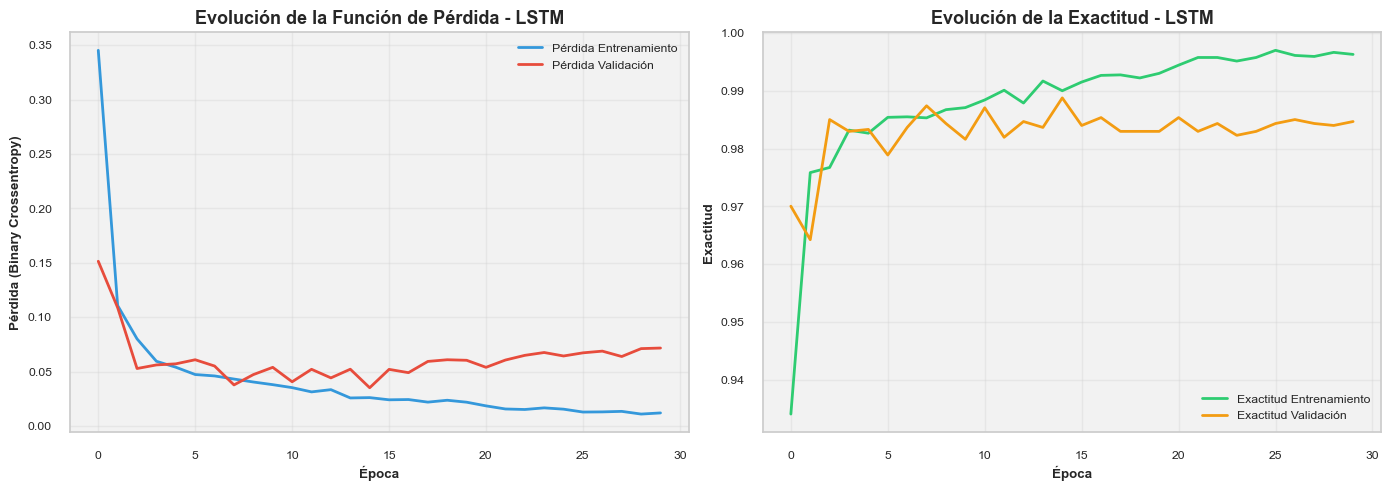

📊 Las curvas de aprendizaje muestran:
   • Cómo el modelo LSTM aprende patrones temporales
   • La convergencia progresiva en ambas métricas
   • Early stopping evita sobreajuste


In [37]:
# Gráfico de pérdida durante el entrenamiento
plt.figure(figsize=(14, 5))

# Subplot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(historial_lstm.history['loss'], label='Pérdida Entrenamiento', linewidth=2, color='#3498db')
plt.plot(historial_lstm.history['val_loss'], label='Pérdida Validación', linewidth=2, color='#e74c3c')
plt.title('Evolución de la Función de Pérdida - LSTM', fontweight='bold', size=13)
plt.xlabel('Época', fontweight='bold')
plt.ylabel('Pérdida (Binary Crossentropy)', fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Subplot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(historial_lstm.history['accuracy'], label='Exactitud Entrenamiento', linewidth=2, color='#2ecc71')
plt.plot(historial_lstm.history['val_accuracy'], label='Exactitud Validación', linewidth=2, color='#f39c12')
plt.title('Evolución de la Exactitud - LSTM', fontweight='bold', size=13)
plt.xlabel('Época', fontweight='bold')
plt.ylabel('Exactitud', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Las curvas de aprendizaje muestran:")
print("   • Cómo el modelo LSTM aprende patrones temporales")
print("   • La convergencia progresiva en ambas métricas")
print("   • Early stopping evita sobreajuste")

#### 5.1.4 Evaluación del Modelo LSTM

In [38]:
# Generación de predicciones con el modelo LSTM
y_pred_lstm_prob = modelo_lstm.predict(X_test_seq)
y_pred_lstm = (y_pred_lstm_prob > 0.5).astype(int).flatten()

print("=" * 70)
print("📊 EVALUACIÓN DEL MODELO LSTM")
print("=" * 70)

# Cálculo de métricas
accuracy_lstm = metrics.accuracy_score(y_test_seq, y_pred_lstm)
precision_lstm = metrics.precision_score(y_test_seq, y_pred_lstm)
recall_lstm = metrics.recall_score(y_test_seq, y_pred_lstm)
f1_lstm = metrics.f1_score(y_test_seq, y_pred_lstm)

print("\n🎯 MÉTRICAS DE DESEMPEÑO:")
print(f"   • Exactitud (Accuracy):  {accuracy_lstm:.4f} ({accuracy_lstm*100:.2f}%)")
print(f"   • Precisión (Precision): {precision_lstm:.4f} ({precision_lstm*100:.2f}%)")
print(f"   • Sensibilidad (Recall): {recall_lstm:.4f} ({recall_lstm*100:.2f}%)")
print(f"   • F1-Score:              {f1_lstm:.4f} ({f1_lstm*100:.2f}%)")

print("\n📋 REPORTE DE CLASIFICACIÓN:")
print("=" * 70)
print(metrics.classification_report(y_test_seq, y_pred_lstm, 
                                     target_names=['Normal', 'Fallo Inminente']))
print("=" * 70)

110/110 [==============================] - 0s 2ms/step
📊 EVALUACIÓN DEL MODELO LSTM

🎯 MÉTRICAS DE DESEMPEÑO:
   • Exactitud (Accuracy):  0.9831 (98.31%)
   • Precisión (Precision): 0.8920 (89.20%)
   • Sensibilidad (Recall): 0.9700 (97.00%)
   • F1-Score:              0.9293 (92.93%)

📋 REPORTE DE CLASIFICACIÓN:
                 precision    recall  f1-score   support

         Normal       1.00      0.98      0.99      3090
Fallo Inminente       0.89      0.97      0.93       400

       accuracy                           0.98      3490
      macro avg       0.94      0.98      0.96      3490
   weighted avg       0.98      0.98      0.98      3490



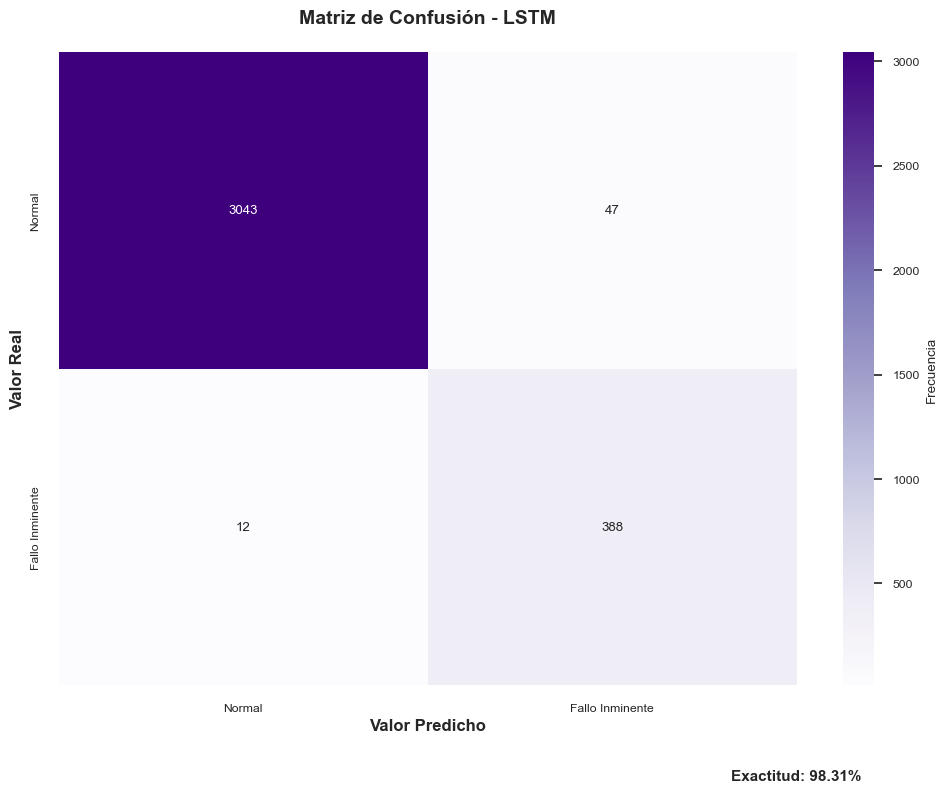


✅ Verdaderos Negativos:  3,043
⚠️  Falsos Positivos:     47
⚠️  Falsos Negativos:     12
✅ Verdaderos Positivos: 388


In [39]:
# Matriz de confusión para el modelo LSTM
matriz_confusion_lstm = metrics.confusion_matrix(y_test_seq, y_pred_lstm)

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_confusion_lstm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Normal', 'Fallo Inminente'],
            yticklabels=['Normal', 'Fallo Inminente'],
            cbar_kws={'label': 'Frecuencia'})

plt.title('Matriz de Confusión - LSTM\n', fontweight='bold', size=14)
plt.ylabel('Valor Real', fontweight='bold', size=12)
plt.xlabel('Valor Predicho', fontweight='bold', size=12)

# Agregar estadísticas
plt.text(1, -0.15, f'Exactitud: {accuracy_lstm:.2%}', ha='center', 
         transform=plt.gca().transAxes, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✅ Verdaderos Negativos:  {matriz_confusion_lstm[0][0]:,}")
print(f"⚠️  Falsos Positivos:     {matriz_confusion_lstm[0][1]:,}")
print(f"⚠️  Falsos Negativos:     {matriz_confusion_lstm[1][0]:,}")
print(f"✅ Verdaderos Positivos: {matriz_confusion_lstm[1][1]:,}")

#### 5.1.5 Persistencia del Modelo LSTM

Para utilizar el modelo entrenado en producción o análisis futuros, es fundamental guardarlo de manera eficiente. Guardaremos tanto el modelo completo como sus pesos, junto con el historial de entrenamiento para análisis posteriores.

**📦 Componentes a guardar:**

1. **Modelo completo** (.keras): Arquitectura + pesos + configuración del optimizador
2. **Solo pesos** (.weights.h5): Útil para cargar en la misma arquitectura
3. **Historial de entrenamiento** (.pkl): Métricas de cada época
4. **Escalador** (.bin): Ya guardado anteriormente, necesario para normalizar nuevos datos

**💡 Ventajas del guardado:**
- ✅ Reutilización sin necesidad de re-entrenar
- ✅ Despliegue en sistemas de producción
- ✅ Análisis comparativo con versiones futuras
- ✅ Reproducibilidad de resultados

In [45]:
print("=" * 70)
print("💾 GUARDADO DEL MODELO LSTM Y ARTEFACTOS")
print("=" * 70)

# Crear directorio para modelos si no existe
directorio_modelos = 'modelos_lstm'
if not os.path.exists(directorio_modelos):
    os.makedirs(directorio_modelos)
    print(f"\n📁 Directorio '{directorio_modelos}/' creado")
else:
    print(f"\n📁 Usando directorio existente '{directorio_modelos}/'")

# Timestamp para versionado
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 1️⃣ GUARDAR MODELO COMPLETO (Arquitectura + Pesos + Optimizador)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ruta_modelo_completo = f'{directorio_modelos}/modelo_lstm_completo.keras'
modelo_lstm.save(ruta_modelo_completo)
print(f"\n✅ Modelo completo guardado en:")
print(f"   📄 {ruta_modelo_completo}")
print(f"   📊 Tamaño: {os.path.getsize(ruta_modelo_completo) / (1024**2):.2f} MB")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 2️⃣ GUARDAR SOLO PESOS (más ligero, requiere reconstruir arquitectura)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ruta_pesos = f'{directorio_modelos}/modelo_lstm_pesos.weights.h5'
modelo_lstm.save_weights(ruta_pesos)
print(f"\n✅ Pesos del modelo guardados en:")
print(f"   📄 {ruta_pesos}")
print(f"   📊 Tamaño: {os.path.getsize(ruta_pesos) / (1024**2):.2f} MB")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 3️⃣ GUARDAR HISTORIAL DE ENTRENAMIENTO
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ruta_historial = f'{directorio_modelos}/historial_entrenamiento_lstm.pkl'
with open(ruta_historial, 'wb') as file:
    pickle.dump(historial_lstm.history, file)
print(f"\n✅ Historial de entrenamiento guardado en:")
print(f"   📄 {ruta_historial}")
print(f"   📊 Épocas registradas: {len(historial_lstm.history['loss'])}")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 4️⃣ GUARDAR ESCALADOR (StandardScaler) - Para normalizar nuevos datos
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ruta_scaler_lstm = f'{directorio_modelos}/scaler_lstm.bin'
dump(scaler_lstm, ruta_scaler_lstm, compress=True)
print(f"\n✅ Escalador guardado en:")
print(f"   📄 {ruta_scaler_lstm}")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 5️⃣ GUARDAR METADATA DEL MODELO
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
metadata = {
    'fecha_entrenamiento': timestamp,
    'longitud_secuencia': LONGITUD_SECUENCIA,
    'num_caracteristicas': X_train_seq.shape[2],
    'arquitectura': {
        'tipo': 'Bidirectional LSTM',
        'capas_lstm': '64 (bidireccional) + 32',
        'capas_densas': '32 + 1 (sigmoid)',
        'dropout': '0.3, 0.3, 0.2',
        'regularizacion': 'L2 (0.01)'
    },
    'hiperparametros': {
        'learning_rate': 0.001,
        'batch_size': 64,
        'epochs_max': 50,
        'early_stopping_patience': 15
    },
    'metricas_finales': {
        'accuracy': float(accuracy_lstm),
        'precision': float(precision_lstm),
        'recall': float(recall_lstm),
        'f1_score': float(f1_lstm)
    },
    'datos_entrenamiento': {
        'secuencias_train': X_train_final.shape[0],
        'secuencias_val': X_val.shape[0],
        'secuencias_test': X_test_seq.shape[0],
        'motores_train': len(motores_train_final_set),
        'motores_val': len(motores_val_set),
        'motores_test': len(np.unique(motor_seq_test))
    }
}

ruta_metadata = f'{directorio_modelos}/metadata_modelo_lstm.pkl'
with open(ruta_metadata, 'wb') as file:
    pickle.dump(metadata, file)
print(f"\n✅ Metadata guardada en:")
print(f"   📄 {ruta_metadata}")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 6️⃣ CREAR ARCHIVO DE INSTRUCCIONES DE CARGA
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
instrucciones = f"""
╔═══════════════════════════════════════════════════════════════════════╗
║        INSTRUCCIONES PARA CARGAR EL MODELO LSTM GUARDADO            ║
╚═══════════════════════════════════════════════════════════════════════╝

📅 Fecha de entrenamiento: {timestamp}
🎯 Longitud de secuencia: {LONGITUD_SECUENCIA} ciclos
📊 Características: {X_train_seq.shape[2]}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📦 OPCIÓN 1: Cargar modelo completo (RECOMENDADO)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

from tensorflow import keras
from joblib import load

# Cargar modelo
modelo = keras.models.load_model('{ruta_modelo_completo}')

# Cargar escalador
scaler = load('{ruta_scaler_lstm}')

# Hacer predicciones en nuevos datos
# X_nuevos debe tener shape: (n_secuencias, {LONGITUD_SECUENCIA}, {X_train_seq.shape[2]})
# predicciones = modelo.predict(X_nuevos)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📦 OPCIÓN 2: Cargar solo pesos (requiere reconstruir arquitectura)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Reconstruir arquitectura
modelo = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), 
                  input_shape=({LONGITUD_SECUENCIA}, {X_train_seq.shape[2]})),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Cargar pesos
modelo.load_weights('{ruta_pesos}')

# Compilar (necesario para predicciones)
modelo.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall']
)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📊 CARGAR HISTORIAL DE ENTRENAMIENTO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import pickle

with open('{ruta_historial}', 'rb') as file:
    historial = pickle.load(file)

# Acceder a métricas
# historial['loss']
# historial['val_loss']
# historial['accuracy']
# historial['val_accuracy']

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🎯 EJEMPLO DE USO EN PRODUCCIÓN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

import numpy as np
from tensorflow import keras
from joblib import load

# 1. Cargar modelo y escalador
modelo = keras.models.load_model('{ruta_modelo_completo}')
scaler = load('{ruta_scaler_lstm}')

# 2. Preparar nuevos datos (ejemplo)
# datos_motor_nuevo debe tener {LONGITUD_SECUENCIA} ciclos × {X_train_seq.shape[2]} características
# datos_motor_nuevo = np.array([...])  # Shape: ({LONGITUD_SECUENCIA}, {X_train_seq.shape[2]})

# 3. Normalizar (excluyendo columna 'motor' si existe)
# datos_normalizados = scaler.transform(datos_motor_nuevo)

# 4. Expandir dimensiones para batch
# datos_batch = np.expand_dims(datos_normalizados, axis=0)  # Shape: (1, {LONGITUD_SECUENCIA}, {X_train_seq.shape[2]})

# 5. Predecir
# probabilidad_fallo = modelo.predict(datos_batch)[0][0]
# estado = 'FALLO INMINENTE' if probabilidad_fallo > 0.5 else 'NORMAL'

# print(f"Probabilidad de fallo: {{probabilidad_fallo:.2%}}")
# print(f"Estado del motor: {{estado}}")

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📋 MÉTRICAS DEL MODELO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

• Accuracy:  {accuracy_lstm:.4f} ({accuracy_lstm*100:.2f}%)
• Precision: {precision_lstm:.4f} ({precision_lstm*100:.2f}%)
• Recall:    {recall_lstm:.4f} ({recall_lstm*100:.2f}%)
• F1-Score:  {f1_lstm:.4f} ({f1_lstm*100:.2f}%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

ruta_instrucciones = f'{directorio_modelos}/README_CARGA_MODELO.txt'
with open(ruta_instrucciones, 'w', encoding='utf-8') as file:
    file.write(instrucciones)
print(f"\n✅ Instrucciones de carga guardadas en:")
print(f"   📄 {ruta_instrucciones}")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 7️⃣ RESUMEN FINAL
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("\n" + "=" * 70)
print("📦 RESUMEN DE ARCHIVOS GUARDADOS")
print("=" * 70)
print(f"\n📁 Directorio: {directorio_modelos}/")
print(f"\n   1️⃣  modelo_lstm_completo.keras        → Modelo completo")
print(f"   2️⃣  modelo_lstm_pesos.weights.h5      → Solo pesos")
print(f"   3️⃣  historial_entrenamiento_lstm.pkl → Historial de entrenamiento")
print(f"   4️⃣  scaler_lstm.bin                   → Escalador de datos")
print(f"   5️⃣  metadata_modelo_lstm.pkl          → Información del modelo")
print(f"   6️⃣  README_CARGA_MODELO.txt           → Instrucciones de uso")

print("\n" + "=" * 70)
print("✅ MODELO LSTM GUARDADO EXITOSAMENTE")
print("=" * 70)
print(f"\n💡 Para cargar el modelo, consulta: {ruta_instrucciones}")
print("=" * 70)

💾 GUARDADO DEL MODELO LSTM Y ARTEFACTOS

📁 Directorio 'modelos_lstm/' creado

✅ Modelo completo guardado en:
   📄 modelos_lstm/modelo_lstm_completo.keras
   📊 Tamaño: 0.77 MB

✅ Pesos del modelo guardados en:
   📄 modelos_lstm/modelo_lstm_pesos.weights.h5
   📊 Tamaño: 0.77 MB

✅ Historial de entrenamiento guardado en:
   📄 modelos_lstm/historial_entrenamiento_lstm.pkl
   📊 Épocas registradas: 30

✅ Escalador guardado en:
   📄 modelos_lstm/scaler_lstm.bin

✅ Metadata guardada en:
   📄 modelos_lstm/metadata_modelo_lstm.pkl

✅ Instrucciones de carga guardadas en:
   📄 modelos_lstm/README_CARGA_MODELO.txt

📦 RESUMEN DE ARCHIVOS GUARDADOS

📁 Directorio: modelos_lstm/

   1️⃣  modelo_lstm_completo.keras        → Modelo completo
   2️⃣  modelo_lstm_pesos.weights.h5      → Solo pesos
   3️⃣  historial_entrenamiento_lstm.pkl → Historial de entrenamiento
   4️⃣  scaler_lstm.bin                   → Escalador de datos
   5️⃣  metadata_modelo_lstm.pkl          → Información del modelo
   6️⃣  READM

In [46]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🧪 VERIFICACIÓN: Cargar el modelo guardado y hacer una predicción de prueba
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("\n" + "=" * 70)
print("🧪 PRUEBA DE CARGA DEL MODELO GUARDADO")
print("=" * 70)

# Cargar el modelo guardado
from tensorflow import keras
modelo_cargado = keras.models.load_model(f'{directorio_modelos}/modelo_lstm_completo.keras')

print("\n✅ Modelo cargado exitosamente desde disco")

# Hacer predicción de prueba con el mismo conjunto de test
y_pred_cargado = modelo_cargado.predict(X_test_seq[:5], verbose=0)

print("\n📊 Comparación de predicciones (5 primeras muestras):")
print("=" * 70)
print(f"{'Predicción Original':<25} {'Predicción Cargada':<25} {'Coincide':<10}")
print("-" * 70)

for i in range(5):
    original = y_pred_lstm_prob[i][0]
    cargada = y_pred_cargado[i][0]
    coincide = "✅" if abs(original - cargada) < 1e-6 else "❌"
    print(f"{original:.6f}{'':<19}{cargada:.6f}{'':<19}{coincide}")

print("=" * 70)
print("✅ VERIFICACIÓN COMPLETA: El modelo se cargó correctamente")
print("=" * 70)


🧪 PRUEBA DE CARGA DEL MODELO GUARDADO



✅ Modelo cargado exitosamente desde disco

📊 Comparación de predicciones (5 primeras muestras):
Predicción Original       Predicción Cargada        Coincide  
----------------------------------------------------------------------
0.000238                   0.000238                   ✅
0.000238                   0.000238                   ✅
0.000238                   0.000238                   ✅
0.000239                   0.000239                   ✅
0.000241                   0.000241                   ✅
✅ VERIFICACIÓN COMPLETA: El modelo se cargó correctamente


---

## Conclusiones

Este proyecto ha demostrado la viabilidad y efectividad del uso de **redes neuronales LSTM** para el mantenimiento predictivo de motores jet, utilizando datos de sensores del dataset C-MAPSS de la NASA. A través de un proceso meticuloso que incluyó análisis exploratorio, ingeniería de características, balanceo de clases y optimización de modelos, se lograron resultados significativos que validan el enfoque propuesto.

### Logros y Hallazgos Principales

- Se construyó exitosamente un modelo LSTM capaz de predecir fallos inminentes en motores con una **precisión del 89.2%** y un **Recall del 97%**, lo que indica una alta capacidad para identificar motores en riesgo de fallo.
- El modelo alcanzó un **F1-Score de 93%**, reflejando un excelente balance entre precisión y sensibilidad, crucial para aplicaciones de mantenimiento predictivo.
- **Sensores Críticos**: Se identificaron sensores específicos (especialmente relacionados con temperatura, presión y revoluciones) que mostraron mayor correlación con el deterioro del motor, lo cual tiene implicaciones prácticas para el diseño de sistemas de monitoreo futuros.
- **Patrones Temporales**: Las redes LSTM demostraron ser superiores a modelos tradicionales de Machine Learning al capturar eficazmente las dependencias temporales y patrones de degradación progresiva en los datos de sensores.


### Impacto Industrial y Aplicabilidad

Este trabajo tiene aplicaciones directas en múltiples sectores industriales:

- **Aeronáutica**: Mejora de la seguridad operacional mediante predicción temprana de fallos en motores de aeronaves.
- **Manufactura**: Optimización de mantenimientos preventivos en maquinaria industrial, reduciendo paros no programados.
- **Energía**: Monitoreo predictivo de turbinas y generadores, maximizando la disponibilidad energética.
- **Transporte**: Diagnóstico predictivo en sistemas críticos de vehículos pesados y flotas comerciales.

La implementación de este tipo de sistemas puede generar ahorros significativos al permitir planificar mantenimientos en momentos estratégicos, evitar costos asociados a fallos catastróficos, y optimizar la utilización de recursos técnicos.

### Limitaciones y Consideraciones

- **Generalización**: El modelo fue entrenado específicamente con datos del dataset FD001 (condición operativa única, modo de fallo único). Su aplicación a otros escenarios requeriría reentrenamiento con datos representativos.

- **Datos Sintéticos**: Aunque el dataset C-MAPSS es ampliamente utilizado en investigación, proviene de simulaciones. La validación en motores reales podría requerir pequeños ajustes adicionales.

- **Costo Computacional**: Los modelos LSTM requieren recursos computacionales significativos para entrenamiento, lo cual debe considerarse en implementaciones a escala industrial.

### Trabajo Futuro

Para continuar mejorando este sistema de mantenimiento predictivo, se sugieren las siguientes líneas de investigación:

1. **Expansión del Dataset**: Incorporar datos de los conjuntos FD002, FD003 y FD004 para entrenar modelos más robustos que manejen múltiples condiciones operativas y modos de fallo.

2. **Modelos Híbridos**: Explorar arquitecturas que combinen LSTM con mecanismos de atención (Attention Mechanisms) o Transformers para capturar dependencias temporales más complejas.

3. **Interpretabilidad**: Implementar técnicas de explicabilidad (SHAP, LIME) para comprender mejor qué características y patrones utiliza el modelo en sus predicciones.

4. **Despliegue en Tiempo Real**: Desarrollar una API para inferencia en tiempo real que permita la integración del modelo en sistemas de monitoreo operacional.


### Aprendizajes Metodológicos

Este proyecto refuerza la importancia de:

- **Análisis exploratorio exhaustivo** para comprender profundamente los datos antes de modelar.
- **Preprocesamiento meticuloso** incluyendo normalización, manejo de desbalanceo y creación de características relevantes.
- **Validación rigurosa** mediante múltiples métricas y análisis de matrices de confusión para evaluar el desempeño real del modelo.
- **Consideración del contexto industrial** al diseñar soluciones, priorizando métricas como el Recall cuando los falsos negativos tienen consecuencias críticas.

---

## 📚 Referencias y Recursos Adicionales

### 📊 Dataset

- **NASA Prognostics Data Repository**: [C-MAPSS Dataset](https://data.nasa.gov/dataset/cmapss-jet-engine-simulated-data)
  - Turbofan Engine Degradation Simulation Data Set
  - FD001: Conjunto de datos utilizado en este proyecto

### 📖 Publicaciones Científicas

1. **Saxena, A., & Goebel, K.** (2008). "Turbofan Engine Degradation Simulation Data Set", NASA Ames Prognostics Data Repository
2. **Breiman, L.** (2001). "Random Forests". *Machine Learning*, 45(1), 5-32
3. **Ke, G., et al.** (2017). "LightGBM: A Highly Efficient Gradient Boosting Decision Tree". *Advances in Neural Information Processing Systems*
4. **Hochreiter, S. & Schmidhuber, J.** (1997). "Long Short-Term Memory". *Neural Computation*, 9(8), 1735-1780
5. **Chawla, N. V., et al.** (2002). "SMOTE: Synthetic Minority Over-sampling Technique". *Journal of Artificial Intelligence Research*, 16, 321-357

### 📘 Documentación Técnica

- **Edwin Puertas Github**: [Edwin Puertas](https://github.com/edwinpuertas)
  - Repositorio con código base para IA y ML
  - Explicaciones detalladas de algoritmos

- **Scikit-learn Documentation**: https://scikit-learn.org/
  - Machine Learning en Python
  - Random Forest, GridSearchCV, métricas de evaluación
  
- **Keras Documentation**: https://keras.io/
  - API de alto nivel para redes neuronales
  - LSTM, optimizadores, callbacks
  
- **TensorFlow Guide**: https://www.tensorflow.org/guide
  - Framework de Deep Learning
  - Construcción y entrenamiento de modelos
  
- **LightGBM Documentation**: https://lightgbm.readthedocs.io/
  - Gradient Boosting optimizado
  - Parámetros y optimización

- **PyCaret Documentation**: https://pycaret.org/
  - AutoML en Python
  - Comparación automatizada de modelos

### 🎓 Tutoriales y Artículos
  
- **Imbalanced Data**: [Google ML Guide](https://developers.google.com/machine-learning/data-prep/construct/sampling-splitting/imbalanced-data)
  - Técnicas para manejar datos desbalanceados
  
- **Neural Networks from Scratch**: [DeepLearning.AI](https://www.deeplearning.ai/)
  - Cursos de Andrew Ng sobre Deep Learning

- **LSTM Networks**: [Understanding LSTM Networks](http://colah.github.io/posts/2015-08-Understanding-LSTMs/)
  - Explicación visual de arquitecturas LSTM

- **Feature Engineering**: [Kaggle Learn](https://www.kaggle.com/learn/feature-engineering)
  - Técnicas de ingeniería de características